In [1]:
GRAY_TO_CLASS = {0: -1, 64: 0, 128: 1, 192: 2, 255: 3}  # -1 = background, ignorado
CLASS_NAMES = ["No_Proliferativo", "Proliferativo", "Esclerosado", "Excluido"]
CONFIG = {
    # Paths — leer desde Entradas/ (tiles crudos + máscaras manuales)
    'images_dir': 'Salidas/Clasificador/crops',              # Already-fused crops: <slide>/images/*.png
    'masks_dir':  'Salidas/Clasificador/crops',              # Pre-computed masks: <slide>/masks/*.png
    'output_dir': 'Salidas/Clasificador',
    # Split — MISMO que U-Net
    'train_size': 0.70,
    'val_size':   0.15,
    'seed':       42,
    # Crop/reconstruction
    'input_size':   224,
    'mask_size':    224,
    'margin_ratio': 0.25,
    'min_area_px':  1500,
    'min_distance': 15,
    'force_rebuild_manifest': False,  # True para ignorar Salidas/Clasificador/manifest.csv y reconstruirlo
    'manifest_primary_only': True,     # Usar solo glomérulos primary del annotations.json
    # Model
    'backbone':    'efficientnet_b0',
    'input_mode':  'rgb_mask_manual',
    'num_classes': 4,
    'pretrained':  True,
    # Training
    'max_epochs':      80,
    'batch_size':  32,
    'lr':          3e-4,
    'weight_decay': 1e-4,
    'warmup_epochs': 5,
    'use_amp':     True,
    'early_stopping_patience': 12,
    'early_stopping_min_delta': 1e-4,
    # Loss & Sampling strategy
    'loss_fn': 'cross_entropy',  # 'cross_entropy' o 'focal'
    'sampling_strategy': 'sampler_balanced_ce_unweighted',
}

In [2]:
# Standard library
import os
import json
import random
import warnings
from pathlib import Path
from typing import Tuple
# Scientific computing / ML
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import albumentations as A
import timm
import matplotlib.pyplot as plt
# Data loading and metrics
from PIL import Image, ImageFile
from scipy.ndimage import label as scipy_label, distance_transform_edt
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, precision_recall_fscore_support, accuracy_score
from skimage.feature import peak_local_max as _plm
from skimage.measure import regionprops
from skimage.segmentation import watershed as _watershed
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm
# Allow PIL to load truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True
# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
# --- CUDA performance tuning (T4 Tensor Cores) ---
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True          # auto-tune conv algorithms
    torch.backends.cuda.matmul.allow_tf32 = True   # TF32 for matmul (T4 supports it)
    torch.backends.cudnn.allow_tf32 = True         # TF32 for cudnn convolutions
    print(f"cudnn.benchmark: {torch.backends.cudnn.benchmark}")
    print(f"CUDA matmul TF32: {torch.backends.cuda.matmul.allow_tf32}")
    print(f"cudnn TF32: {torch.backends.cudnn.allow_tf32}")
    print(f"PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True")
# --- Preprocessing Transforms (Reinhard Normalization + Z-score) ---
class ReinhardNormalize:
    """Reinhard stain normalization in LAB color space for consistency across slides."""
    def __init__(self, target_stats: dict):
        self.target = target_stats
    @staticmethod
    def _get_tissue_mask(img_bgr: np.ndarray) -> np.ndarray:
        """Isolate tissue pixels from background and artifacts via luminance and saturation thresholds."""
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
        hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        mask = (lab[:, :, 0] < 230) & (hsv[:, :, 1] > 10)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
        mask = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        return mask.astype(bool)
    @staticmethod
    def compute_template_stats(image_paths: list, n_samples: int = 200) -> dict:
        """Compute median LAB statistics from tissue pixels to define normalization target."""
        paths_list = list(image_paths)[:n_samples]
        sample = random.sample(paths_list, min(n_samples, len(paths_list)))
        all_stats = []
        
        for p in sample:
            img = cv2.imread(str(p))
            if img is None:
                continue
            tissue = ReinhardNormalize._get_tissue_mask(img)
            if tissue.sum() < 100:
                continue
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
            stats = ([lab[..., c][tissue].mean() for c in range(3)] +
                     [lab[..., c][tissue].std()  for c in range(3)])
            all_stats.append(stats)
        
        if not all_stats:
            return {'mean_L': 50, 'mean_a': 128, 'mean_b': 128,
                    'std_L': 10, 'std_a': 10, 'std_b': 10}
        
        arr = np.array(all_stats)
        keys = ['mean_L', 'mean_a', 'mean_b', 'std_L', 'std_a', 'std_b']
        return {k: float(np.median(arr[:, i])) for i, k in enumerate(keys)}
    def __call__(self, img_bgr: np.ndarray) -> np.ndarray:
        """Normalize image to match template statistics, preserving background pixels."""
        tissue = self._get_tissue_mask(img_bgr)
        if tissue.sum() < 100:
            return img_bgr
        
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
        
        src = {c: (lab[..., i][tissue].mean(), lab[..., i][tissue].std())
               for i, c in enumerate(['L', 'a', 'b'])}
        
        result = lab.copy()
        for i, c in enumerate(['L', 'a', 'b']):
            m, s = src[c]
            result[..., i] = ((lab[..., i] - m) *
                              (self.target[f'std_{c}'] / (s + 1e-5)) +
                              self.target[f'mean_{c}'])
        
        result[~tissue] = lab[~tissue]
        result = np.clip(result, 0, 255).astype(np.uint8)
        return cv2.cvtColor(result, cv2.COLOR_LAB2BGR)
def compute_channel_stats(
    image_paths: list,
    n_samples: int = 200,
    reinhard_norm=None,
    std_floor: float = 0.03,
) -> Tuple[list, list]:
    """Compute weighted per-channel RGB stats from tissue pixels for Z-score normalization."""
    paths_list = list(image_paths)
    sample = random.sample(paths_list, min(n_samples, len(paths_list)))
    
    tile_means, tile_vars, tile_counts = [], [], []
    skipped_count = 0
    for p in sample:
        img_bgr = cv2.imread(str(p))
        if img_bgr is None:
            skipped_count += 1
            continue
        tissue = ReinhardNormalize._get_tissue_mask(img_bgr)
        if tissue.sum() < 100:
            skipped_count += 1
            continue
        if reinhard_norm is not None:
            img_bgr = reinhard_norm(img_bgr)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        pixels = img_rgb[tissue]
        tile_means.append(pixels.mean(0))
        tile_vars.append(pixels.var(0))
        tile_counts.append(tissue.sum())
    
    if not tile_means:
        print(f"  ⚠️  WARNING: No valid tissue pixels found in {len(sample)} samples!")
        print(f"      {skipped_count} samples were skipped (tissue.sum() < 100 or read failed)")
        print(f"      Falling back to default values [0.5, 0.5, 0.5] and [0.2, 0.2, 0.2]")
        print(f"      This will make Z-score normalization INEFFECTIVE.")
        return [0.5, 0.5, 0.5], [0.2, 0.2, 0.2]
    
    print(f"  ✓ Computed stats from {len(tile_means)} valid samples (skipped {skipped_count})")
    
    means_arr = np.array(tile_means)
    vars_arr = np.array(tile_vars)
    counts_arr = np.array(tile_counts, dtype=np.float64)
    w = counts_arr / counts_arr.sum()
    
    mean = (means_arr * w[:, None]).sum(0)
    var = ((vars_arr + (means_arr - mean) ** 2) * w[:, None]).sum(0)
    std = np.sqrt(var)
    std = np.maximum(std, std_floor)
    return mean.tolist(), std.tolist()
def _collect_image_tiles(images_dir: str) -> list:
    """Collect input PNG tiles while excluding masks and generated mask files."""
    images_dir = Path(images_dir)
    image_paths = sorted(images_dir.glob('*/images/*.png'))
    # Fallback for flat/custom datasets: include PNGs except anything inside a masks folder
    # or files already named *_mask.png.
    if not image_paths:
        image_paths = sorted(
            p for p in images_dir.rglob('*.png')
            if 'masks' not in p.relative_to(images_dir).parts
            and not p.stem.endswith('_mask')
        )
    return image_paths
def _slide_name_from_image_path(image_path, images_dir) -> str:
    """Infer the biopsy/slide name from a tile path under <root>/<slide>/images/*.png."""
    image_path = Path(image_path)
    images_dir = Path(images_dir)
    try:
        rel = image_path.relative_to(images_dir)
        if len(rel.parts) >= 3 and rel.parts[1] == 'images':
            return rel.parts[0]
    except ValueError as e:
        warnings.warn(f'Path format issue for {image_path}: {e}')
        return None
    if image_path.parent.name == 'images' and image_path.parent.parent.name:
        return image_path.parent.parent.name
    return image_path.parent.name or image_path.stem
def _group_images_by_biopsy(image_paths: list, images_dir: str) -> dict:
    """Group image paths by biopsy/slide folder, supporting canonical and flat layouts."""
    images_dir = Path(images_dir)
    biopsias_dict = {}
    for img_path in image_paths:
        biopsia = _slide_name_from_image_path(img_path, images_dir)
        biopsias_dict.setdefault(biopsia, []).append(img_path)
    return biopsias_dict
def _safe_train_val_test_split(
    biopsias_list: list,
    train_size: float = 0.70,
    val_size: float = 0.15,
    seed: int = 42,
) -> Tuple[list, list, list]:
    """Split biopsy IDs without crashing on tiny datasets."""
    test_size = 1.0 - train_size - val_size
    assert test_size >= 0, "train_size + val_size must be <= 1.0"
    biopsias_list = list(biopsias_list)
    if not biopsias_list:
        return [], [], []
    # sklearn.train_test_split raises on very small lists. Keep deterministic, leak-free
    # biopsy-level splits and prefer having train data in quick/smoke-test datasets.
    if len(biopsias_list) == 1:
        return biopsias_list, [], []
    if len(biopsias_list) == 2:
        rng = random.Random(seed)
        shuffled = biopsias_list[:]
        rng.shuffle(shuffled)
        return [shuffled[0]], [shuffled[1]], []
    if test_size > 0:
        train_val_biopsias, test_biopsias = train_test_split(
            biopsias_list,
            test_size=test_size,
            random_state=seed,
        )
    else:
        train_val_biopsias = biopsias_list
        test_biopsias = []
    if val_size > 0 and len(train_val_biopsias) > 1:
        val_fraction = val_size / (train_size + val_size)
        train_biopsias, val_biopsias = train_test_split(
            train_val_biopsias,
            test_size=val_fraction,
            random_state=seed + 1,
        )
    else:
        train_biopsias = train_val_biopsias
        val_biopsias = []
    return train_biopsias, val_biopsias, test_biopsias
def split_biopsias(
    images_dir: str,
    train_size: float = 0.70,
    val_size: float = 0.15,
    seed: int = 42,
) -> Tuple[list, list, list, dict]:
    """Groups biopsias into train/val/test to prevent data leakage at slide level."""
    images_dir = Path(images_dir)
    all_images = _collect_image_tiles(images_dir)
    if not all_images:
        raise ValueError(f"No PNG image tiles found in {images_dir}. Expected files under */images/*.png")
    biopsias_dict = _group_images_by_biopsy(all_images, images_dir)
    train_biopsias, val_biopsias, test_biopsias = _safe_train_val_test_split(
        list(biopsias_dict.keys()),
        train_size=train_size,
        val_size=val_size,
        seed=seed,
    )
    return train_biopsias, val_biopsias, test_biopsias, biopsias_dict
def load_rgb_image(image_path: str) -> np.ndarray:
    """Load an RGB uint8 image with PIL tolerance for truncated files."""
    try:
        return np.array(Image.open(str(image_path)).convert('RGB'))
    except Exception as exc:
        raise RuntimeError(f"Failed to load image {image_path}: {exc}") from exc
def load_binary_mask(mask_path: str) -> np.ndarray:
    """Load a grayscale mask and binarize all non-zero classes as glomerulus."""
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise RuntimeError(f"Failed to load mask: {mask_path}")
    return (mask > 0).astype(np.uint8)
def preprocess_rgb_image(
    img_rgb: np.ndarray,
    reinhard_norm=None,
    channel_means: list = None,
    channel_stds: list = None,
    reinhard=None,
) -> np.ndarray:
    """Apply the same RGB -> Reinhard -> RGB/255 -> Z-score preprocessing used by the dataset.

    `reinhard` is accepted as an alias because the classifier Dataset stores the
    checkpoint stats under that name. It can be either a ReinhardNormalize object
    or the raw target-stats dict loaded from the U-Net checkpoint.
    """
    if reinhard_norm is None and reinhard is not None:
        reinhard_norm = ReinhardNormalize(reinhard) if isinstance(reinhard, dict) else reinhard

    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    if reinhard_norm is not None:
        img_bgr = reinhard_norm(img_bgr)
    img_float = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    if channel_means is not None and channel_stds is not None:
        means = np.asarray(channel_means, dtype=np.float32)
        stds = np.asarray(channel_stds, dtype=np.float32)
        img_float = (img_float - means) / (stds + 1e-6)
    return img_float
def make_mask_overlay(img_rgb: np.ndarray, mask_binary: np.ndarray, color=(255, 0, 0), alpha: float = 0.4) -> np.ndarray:
    """Blend a binary mask over an RGB image."""
    overlay = img_rgb.copy().astype(np.float32)
    overlay[mask_binary.astype(bool)] = color
    return cv2.addWeighted(img_rgb, 1 - alpha, overlay.astype(np.uint8), alpha, 0)
# ============================================================================
# Grayscale pixel values that correspond to glomerulus classes (any > 0 in practice)
# 64=No_Proliferativo, 128=Proliferativo, 192=Esclerosado, 255=Excluido/Excluyente
# Excluido (255) is INTENTIONALLY mapped to Glomerulus class 1 for binary segmentation
# ============================================================================
# ===== CENTRALIZED POST-PROCESSING FUNCTION =====
# This function is used by threshold tuning, crop extraction, and reconstruction viz
# to ensure CONSISTENCY across all stages
def postprocess_prob_to_instances(
    prob_map,           # H×W float32 probability map (0-1)
    threshold=0.4,
    min_area_px=1500,
    min_distance=15,    # distance between watershed peaks
):
    """
    Consistent post-processing pipeline for all glomerulus detection tasks.
    
    Args:
        prob_map: H×W float32 array in [0, 1]
        threshold: decision threshold
        min_area_px: minimum instance area in pixels
        min_distance: minimum distance between watershed peaks
    
    Returns:
        list of skimage regionprops objects (instances)
    """
    # Step 1: Binary mask from probability
    binary_mask = (prob_map > threshold).astype(np.uint8)
    
    # Step 2: Morphological cleaning (close → open)
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel_close)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel_open)
    
    # Step 3: Watershed-based instance separation
    if binary_mask.sum() < min_area_px:
        return []
    
    distance = distance_transform_edt(binary_mask)
    coords = _plm(distance, min_distance=min_distance, labels=binary_mask)
    
    if len(coords) == 0:
        # Single large region
        coords = np.array([[binary_mask.shape[0]//2, binary_mask.shape[1]//2]])
    
    marker_mask = np.zeros_like(binary_mask, dtype=bool)
    marker_mask[tuple(coords.T)] = True
    markers, _ = scipy_label(marker_mask)
    
    labels_map = _watershed(-distance, markers, mask=binary_mask)
    props = regionprops(labels_map)
    
    # Step 4: Filter by minimum area
    return [p for p in props if p.area >= min_area_px]


c:\Users\proyecto_final\Documents\Proyecto_Final_Glomerulos\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: Tesla T4
VRAM: 17.00 GB
cudnn.benchmark: True
CUDA matmul TF32: True
cudnn TF32: True
PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True


In [3]:
def extract_crop_with_margin(img: np.ndarray, bbox: Tuple[int, int, int, int], margin_ratio: float = 0.25) -> np.ndarray:
    """Extract crop from image with margin around bounding box.
    
    Args:
        img: Image array (H x W or H x W x C)
        bbox: [r_min, c_min, r_max, c_max] bounding box
        margin_ratio: Fraction of height/width to add as margin (default 0.25)
    
    Returns:
        Cropped image array
    """
    h, w = bbox[2] - bbox[0], bbox[3] - bbox[1]
    mh = int(h * margin_ratio)
    mw = int(w * margin_ratio)
    r_min = max(0, bbox[0] - mh)
    r_max = min(img.shape[0], bbox[2] + mh)
    c_min = max(0, bbox[1] - mw)
    c_max = min(img.shape[1], bbox[3] + mw)
    return img[r_min:r_max, c_min:c_max]
def perturb_mask(binary_mask: np.ndarray) -> np.ndarray:
    """Perturba la máscara binaria para simular error de U-Net en entrenamiento."""
    ops = random.choices(['dilate', 'erode', 'close', 'open', 'shift', 'none'], k=1)[0]
    # Handle branches that don't need kernel first
    if ops == 'none':
        return binary_mask
    if ops == 'shift':
        dx, dy = random.randint(-5, 5), random.randint(-5, 5)
        M = np.float32([[1, 0, dx], [0, 1, dy]])
        shifted = cv2.warpAffine(binary_mask.astype(np.uint8), M, binary_mask.shape[::-1])
        return shifted.astype(bool)
    # Create kernel only when needed by morphological operations
    k = random.choice([3, 5])
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    if ops == 'dilate':
        return cv2.dilate(binary_mask.astype(np.uint8), kernel).astype(bool)
    elif ops == 'erode':
        return cv2.erode(binary_mask.astype(np.uint8), kernel).astype(bool)
    elif ops == 'close':
        return cv2.morphologyEx(binary_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel).astype(bool)
    elif ops == 'open':
        return cv2.morphologyEx(binary_mask.astype(np.uint8), cv2.MORPH_OPEN, kernel).astype(bool)
    return binary_mask


In [4]:
def _load_annotations(annotations_path: Path):
    """Load one annotations.json file and validate the minimum fields needed."""
    if not annotations_path.exists():
        warnings.warn(f"annotations.json not found: {annotations_path}")
        return None
    try:
        annotations = json.loads(annotations_path.read_text())
    except Exception as e:
        warnings.warn(f"Could not read {annotations_path}: {e}")
        return None
    if not annotations.get('width_native') or not annotations.get('height_native'):
        warnings.warn(f"Missing width_native or height_native in {annotations_path}")
        return None
    return annotations


def _group_tiles_by_glomerulus(tiles_list: list) -> dict:
    """Build glomerulus_id -> tiles containing that glomerulus."""
    gid_to_tiles = {}
    for tile in tiles_list:
        for ginfo in tile.get('glomeruli', []):
            gid = str(ginfo.get('id'))
            gid_to_tiles.setdefault(gid, []).append(tile)
    return gid_to_tiles


def _select_contributing_tiles(glomerulus_id: str, coverage_info: dict, gid_to_tiles: dict, force_single_tile: bool) -> list:
    """Select tiles for one glomerulus; optionally restrict to the primary tile."""
    primary_tile_name = coverage_info.get('primary_tile')
    tiles = gid_to_tiles.get(str(glomerulus_id), [])
    if not force_single_tile:
        return tiles
    if not primary_tile_name:
        return []
    primary_stem = Path(primary_tile_name).stem
    return [tile for tile in tiles if Path(tile.get('image', '')).stem == primary_stem]


def _native_bounds_from_tiles(contributing_tiles: list, width_native: int, height_native: int, padding_px: int):
    """Return padded native-coordinate bounds (x1, y1, x2, y2) for contributing tiles."""
    bboxes = [tile['bbox_native'] for tile in contributing_tiles if tile.get('bbox_native')]
    if not bboxes:
        return None
    x1 = max(0, min(int(b[0]) for b in bboxes) - padding_px)
    y1 = max(0, min(int(b[1]) for b in bboxes) - padding_px)
    x2 = min(width_native, max(int(b[2]) for b in bboxes) + padding_px)
    y2 = min(height_native, max(int(b[3]) for b in bboxes) + padding_px)
    return x1, y1, x2, y2


def _place_tile_on_canvas(tile: dict, slide_dir: Path, gray_value: int, canvas_state: dict, zoom: float) -> bool:
    """Load one tile and OR its class mask/RGB pixels into the local fused canvas."""
    mask_path = slide_dir / tile['mask']
    image_path = slide_dir / tile['image']
    if not mask_path.exists():
        warnings.warn(f"Mask not found for tile {mask_path}")
        return False
    if not image_path.exists():
        warnings.warn(f"Image not found for tile {image_path}")
        return False

    mask_gray = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if mask_gray is None or image_bgr is None:
        warnings.warn(f"Failed to load mask/image for tile {image_path}")
        return False

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    tile_h, tile_w = mask_gray.shape
    if image_rgb.shape[:2] != (tile_h, tile_w):
        warnings.warn(f"Skipping tile with image/mask size mismatch: {image_path}")
        return False

    bbox_native = tile.get('bbox_native')
    if bbox_native is None or len(bbox_native) != 4:
        warnings.warn(f"Invalid bbox_native in tile {tile.get('image')}")
        return False

    gx1, gy1 = canvas_state['origin_native']
    canvas_h, canvas_w = canvas_state['fused_mask'].shape
    x1, y1, _, _ = map(int, bbox_native)
    x1_canvas = int(round((x1 - gx1) * zoom))
    y1_canvas = int(round((y1 - gy1) * zoom))
    x2_canvas = min(canvas_w, x1_canvas + tile_w)
    y2_canvas = min(canvas_h, y1_canvas + tile_h)
    x1_clip = max(0, x1_canvas)
    y1_clip = max(0, y1_canvas)

    x1_tile = x1_clip - x1_canvas
    y1_tile = y1_clip - y1_canvas
    x2_tile = x1_tile + (x2_canvas - x1_clip)
    y2_tile = y1_tile + (y2_canvas - y1_clip)
    if x2_tile <= x1_tile or y2_tile <= y1_tile:
        return False

    component_mask = (mask_gray == gray_value).astype(np.uint8)
    canvas_state['fused_mask'][y1_clip:y2_canvas, x1_clip:x2_canvas] |= component_mask[y1_tile:y2_tile, x1_tile:x2_tile]
    canvas_state['fused_rgb'][y1_clip:y2_canvas, x1_clip:x2_canvas] = image_rgb[y1_tile:y2_tile, x1_tile:x2_tile]
    canvas_state['tile_coverage'][y1_clip:y2_canvas, x1_clip:x2_canvas] = 1
    return True


def _fuse_glomerulus_tiles(contributing_tiles: list, slide_dir: Path, gray_value: int, bounds_native: tuple, zoom: float):
    """Fuse all tiles for one glomerulus into local RGB and mask canvases."""
    gx1, gy1, gx2, gy2 = bounds_native
    canvas_w = max(1, int(round((gx2 - gx1) * zoom)))
    canvas_h = max(1, int(round((gy2 - gy1) * zoom)))
    canvas_state = {
        'origin_native': (gx1, gy1),
        'fused_mask': np.zeros((canvas_h, canvas_w), dtype=np.uint8),
        'fused_rgb': np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8),
        'tile_coverage': np.zeros((canvas_h, canvas_w), dtype=np.uint8),
    }
    for tile in contributing_tiles:
        _place_tile_on_canvas(tile, slide_dir, gray_value, canvas_state, zoom)
    canvas_state['fused_rgb'][canvas_state['tile_coverage'] == 0] = 255
    return canvas_state


def _largest_component(labeled_mask: np.ndarray, n_components: int):
    """Return the largest connected component id and pixel coordinates."""
    if n_components <= 0:
        return None
    if n_components == 1:
        component_id = 1
    else:
        component_areas = {i: int(np.sum(labeled_mask == i)) for i in range(1, n_components + 1)}
        component_id = max(component_areas, key=component_areas.get)
    rr, cc = np.where(labeled_mask == component_id)
    if len(rr) == 0:
        return None
    return component_id, rr, cc


def _save_fused_crop(
    fused_rgb: np.ndarray,
    labeled_mask: np.ndarray,
    component_id: int,
    bbox_pixels: tuple,
    output_csv: str,
    biopsia: str,
    glomerulus_id: str,
    gray_value: int,
    classifier_input_size: int,
    crop_padding_px: int,
):
    """Crop, resize, and save the fused RGB crop and matching class-valued mask."""
    bbox_r1, bbox_c1, bbox_r2, bbox_c2 = bbox_pixels
    canvas_h, canvas_w = labeled_mask.shape
    r1 = max(0, bbox_r1 - crop_padding_px)
    r2 = min(canvas_h, bbox_r2 + crop_padding_px)
    c1 = max(0, bbox_c1 - crop_padding_px)
    c2 = min(canvas_w, bbox_c2 + crop_padding_px)

    cropped_mask = (labeled_mask[r1:r2, c1:c2] == component_id).astype(np.uint8)
    cropped_rgb = fused_rgb[r1:r2, c1:c2]
    resized_mask = cv2.resize(cropped_mask, (classifier_input_size, classifier_input_size), interpolation=cv2.INTER_NEAREST)
    resized_rgb = cv2.resize(cropped_rgb, (classifier_input_size, classifier_input_size), interpolation=cv2.INTER_LINEAR)

    base_crops_dir = Path(output_csv).parent / 'crops' if output_csv else Path('Salidas/Clasificador') / 'crops'
    images_dir = base_crops_dir / biopsia / 'images'
    masks_dir = base_crops_dir / biopsia / 'masks'
    images_dir.mkdir(parents=True, exist_ok=True)
    masks_dir.mkdir(parents=True, exist_ok=True)

    fused_crop_path = images_dir / f"{biopsia}_gid{glomerulus_id}.png"
    mask_crop_path = masks_dir / f"{biopsia}_gid{glomerulus_id}_mask.png"
    cv2.imwrite(str(fused_crop_path), cv2.cvtColor(resized_rgb, cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(mask_crop_path), (resized_mask * gray_value).astype(np.uint8))
    return fused_crop_path, mask_crop_path


def _summarize_manifest(df: pd.DataFrame):
    """Print a compact manifest summary."""
    print("\nGlomerulus Manifest Summary (from annotations.json, PER-GLOMERULUS FUSION):")
    print(f"  Total glomeruli: {len(df)}")
    print(f"  Unique glomeruli_ids: {df['glomerulus_id'].nunique()}")
    print("  Split distribution:")
    split_counts = df['split'].value_counts()
    for split in ['train', 'val', 'test']:
        count = split_counts.get(split, 0)
        print(f"    {split}: {count} ({100.0 * count / len(df):.1f}%)")
    print("  Class distribution:")
    for class_id, count in df['class_id'].value_counts().sort_index().items():
        class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else "UNKNOWN"
        print(f"    {class_id} ({class_name}): {count} ({100.0 * count / len(df):.1f}%)")
    print("  Tiles per glomerulus:")
    for n_tiles, count in df['n_tiles_in_glomerulus'].value_counts().sort_index().items():
        print(f"    {int(n_tiles)} tiles: {count} glomeruli ({100.0 * count / len(df):.1f}%)")




def build_glomerulus_manifest_simple(
    images_dir: str,
    masks_dir: str,
    split_biopsias_result: dict,
    output_csv: str = None,
    classifier_input_size: int = 224,
) -> pd.DataFrame:
    """Build manifest from already-fused crops without re-fusing tiles.

    Iterates {images_dir}/{slide_id}/images/*.png to find existing crops.
    Each crop is named {slide_id}_gid{N}.png.
    Matches to mask at {masks_dir}/{slide_id}/masks/{slide_id}_gid{N}_mask.png.
    Returns DataFrame with columns: slide_id, glomerulus_id, class_id, class_name,
                                     fused_crop_path, fused_mask_path, split
    """
    images_dir = Path(images_dir)
    masks_dir = Path(masks_dir)
    rows = []

    for split_name in ['train', 'val', 'test']:
        for slide_id in split_biopsias_result.get(split_name, []):
            slide_images_dir = images_dir / slide_id / 'images'
            slide_masks_dir = masks_dir / slide_id / 'masks'

            if not slide_images_dir.exists():
                continue

            # Find all crops for this slide
            for crop_path in slide_images_dir.glob(f"{slide_id}_gid*.png"):
                # Extract glomerulus_id from filename: {slide_id}_gid{N}.png
                match = re.search(r'_gid(\d+)\.png$', crop_path.name)
                if not match:
                    continue
                glomerulus_id = match.group(1)

                # Construct mask path
                mask_path = slide_masks_dir / f"{slide_id}_gid{glomerulus_id}_mask.png"
                if not mask_path.exists():
                    warnings.warn(f"Mask not found for crop {crop_path.name}: {mask_path}")
                    continue

                # Load mask to determine class
                mask_img = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
                if mask_img is None:
                    warnings.warn(f"Could not read mask: {mask_path}")
                    continue

                # Find the non-zero gray value in mask
                unique_vals = np.unique(mask_img)
                unique_vals = unique_vals[unique_vals != 0]  # Exclude background

                if len(unique_vals) == 0:
                    warnings.warn(f"Mask has no non-zero values: {mask_path}")
                    continue

                gray_value = int(unique_vals[0])  # Use first non-zero value
                class_id = GRAY_TO_CLASS.get(gray_value, -1)

                if class_id == -1:
                    warnings.warn(f"Unknown gray value {gray_value} in {mask_path}")
                    continue

                class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else "UNKNOWN"

                rows.append({
                    'slide_id': slide_id,
                    'glomerulus_id': glomerulus_id,
                    'class_id': class_id,
                    'class_name': class_name,
                    'fused_crop_path': str(crop_path),
                    'fused_mask_path': str(mask_path),
                    'split': split_name,
                })

    manifest_df = pd.DataFrame(rows)

    if output_csv:
        output_csv = Path(output_csv)
        output_csv.parent.mkdir(parents=True, exist_ok=True)
        manifest_df.to_csv(output_csv, index=False)
        print(f"Manifest saved: {output_csv} ({len(manifest_df)} instances)")

    # Print summary
    if len(manifest_df) > 0:
        print("\nGlomerulus Manifest Summary (from pre-fused crops):")
        print(f"  Total glomeruli: {len(manifest_df)}")
        print(f"  Unique slide_ids: {manifest_df['slide_id'].nunique()}")
        print("  Split distribution:")
        split_counts = manifest_df['split'].value_counts()
        for split in ['train', 'val', 'test']:
            count = split_counts.get(split, 0)
            pct = 100.0 * count / len(manifest_df) if len(manifest_df) > 0 else 0
            print(f"    {split}: {count} ({pct:.1f}%)")
        print("  Class distribution:")
        for class_id in sorted(manifest_df['class_id'].unique()):
            count = len(manifest_df[manifest_df['class_id'] == class_id])
            class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else "UNKNOWN"
            pct = 100.0 * count / len(manifest_df) if len(manifest_df) > 0 else 0
            print(f"    {class_id} ({class_name}): {count} ({pct:.1f}%)")

    return manifest_df


def get_manifest_csv_path(config: dict) -> Path:
    """Return the canonical cached manifest path for the classifier pipeline."""
    return Path(config['output_dir']) / 'manifest.csv'


def load_or_build_glomerulus_manifest(
    config: dict,
    split_biopsias_result: dict,
    force_rebuild: bool = False,
) -> pd.DataFrame:
    """Load the cached glomerulus manifest when available; otherwise build it once."""
    output_csv = get_manifest_csv_path(config)
    if output_csv.exists() and not force_rebuild:
        manifest_df = pd.read_csv(output_csv)
        print(f"✓ Loaded cached manifest: {output_csv} ({len(manifest_df)} instances)")
        required_cols = {
            'slide_id', 'glomerulus_id', 'component_id', 'class_name', 'class_id',
            'gray_value', 'bbox_r1', 'bbox_c1', 'bbox_r2', 'bbox_c2',
            'area_px', 'fused_crop_path', 'fused_mask_path', 'split'
        }
        missing_cols = required_cols.difference(manifest_df.columns)
        if not missing_cols:
            return manifest_df
        print(
            f"⚠️ Cached manifest is missing JSON reconstruction columns {sorted(missing_cols)}; "
            "rebuilding from annotations.json."
        )
    if force_rebuild and output_csv.exists():
        print(f"↻ Rebuilding manifest because force_rebuild=True: {output_csv}")
    else:
        print(f"Building manifest from annotations.json: {output_csv}")
    return build_glomerulus_manifest_simple(
        images_dir=config['images_dir'],
        masks_dir=config['masks_dir'],
        split_biopsias_result=split_biopsias_result,
        output_csv=str(output_csv),
        classifier_input_size=config.get('input_size', 224),
    ),


In [5]:
def validate_manifest(manifest_df: pd.DataFrame, output_dir: str = 'Salidas/Clasificador'):
    """
    Validate manifest: print distribution, warnings, and visual grid.
    """
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # === 1. Distribution table ===
    print("\n=== MANIFEST DISTRIBUTION ===")
    print(f"Total instances: {len(manifest_df)}")
    
    # By class and split
    print("\nBy class and split:")
    dist_table = pd.crosstab(
        manifest_df['class_name'],
        manifest_df['split'],
        margins=True
    )
    print(dist_table)
    
    # By biopsy and class
    print("\nTop 10 biopsies by instance count:")
    biopsy_counts = manifest_df['slide_id'].value_counts().head(10)
    print(biopsy_counts)
    
    # === 2. Check for class imbalance warnings ===
    for split in ['train', 'val', 'test']:
        split_df = manifest_df[manifest_df['split'] == split]
        for cls in CLASS_NAMES:
            count = len(split_df[split_df['class_name'] == cls])
            if count == 0:
                print(f"⚠️  WARNING: {cls} has 0 instances in {split} split!")
            elif count < 5:
                print(f"⚠️  WARNING: {cls} has only {count} instances in {split} split")
    
    # === 3. Visual grid: N=8 crops per class ===
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(len(CLASS_NAMES), 8, figure=fig, hspace=0.4, wspace=0.3)
    
    for class_idx, class_name in enumerate(CLASS_NAMES):
        class_df = manifest_df[manifest_df['class_name'] == class_name].head(8)
        
        for crop_idx, (_, row) in enumerate(class_df.iterrows()):
            ax = fig.add_subplot(gs[class_idx, crop_idx])
            
            try:
                # Load RGB
                crop_rgb = load_rgb_image(row['fused_crop_path'])
                
                # Display
                ax.imshow(crop_rgb)
                ax.set_title(f"{class_name}\n{row['slide_id'][:15]}\narea={row.get('area_px', '?')}", fontsize=8)
                ax.axis('off')
            except Exception as e:
                ax.text(0.5, 0.5, f"Error: {str(e)[:20]}", ha='center', va='center', fontsize=8)
                ax.axis('off')
    
    # Save figure
    fig_path = output_dir / 'manifest_visual_grid.png'
    plt.savefig(fig_path, dpi=100, bbox_inches='tight')
    plt.close()
    print(f"\n✓ Saved visual grid to {fig_path}")
    
    # === 4. Compute area statistics ===
    if 'area_px' not in manifest_df.columns:
        # Compute area from bbox if not present
        manifest_df['area_px'] = (manifest_df['bbox_r2'] - manifest_df['bbox_r1']) * (manifest_df['bbox_c2'] - manifest_df['bbox_c1'])
    
    print("\nArea statistics (pixels) by class:")
    area_stats = manifest_df.groupby('class_name')['area_px'].agg(['min', 'mean', 'max', 'count'])
    print(area_stats)
    
    return manifest_df


In [6]:
class GlomeruliClassificationDataset(Dataset):
    """Carga instancias de glomérulos desde manifest pandas.
    
    Extrae crops on-the-fly vía bbox+margin, aplica augmentations,
    retorna tensores 3-channel (RGB) o 4-channel [RGB + máscara] según input_mode.
    """
    
    def __init__(
        self,
        manifest_df: pd.DataFrame,
        images_dir: str,
        masks_dir: str,
        input_size: int = 224,
        mask_size: int = 224,
        margin_ratio: float = 0.25,
        split: str = 'train',
        config: dict = None,
        channel_means: np.ndarray = None,
        channel_stds: np.ndarray = None,
        reinhard: dict = None,
    ):
        self.manifest_df = manifest_df[manifest_df['split'] == split].reset_index(drop=True)
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.input_size = input_size
        self.mask_size = mask_size
        self.margin_ratio = margin_ratio
        self.split = split
        self.config = config or {}
        self.channel_means = channel_means
        self.channel_stds = channel_stds
        self.reinhard = reinhard
        
        # Augmentations solo para train
        self.use_augment = (split == 'train')
        if self.use_augment:
            self.transform = A.Compose([
                A.ElasticTransform(p=0.10, border_mode=cv2.BORDER_REFLECT),
                A.GridDistortion(p=0.10, border_mode=cv2.BORDER_REFLECT),
                A.HEStain(p=0.25),
                A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
                A.GaussNoise(p=0.1),
                A.CoarseDropout(num_holes_range=(1, 1), hole_height_range=(32, 32), hole_width_range=(32, 32), p=0.1),
            ], additional_targets={'mask': 'mask'})
        else:
            self.transform = None
    
    def __len__(self):
        return len(self.manifest_df)
    
    def __getitem__(self, idx):
        row = self.manifest_df.iloc[idx]
        
        # Load pre-fused and pre-cropped RGB image
        fused_crop_path = row['fused_crop_path']
        rgb_crop = load_rgb_image(fused_crop_path)  # Already cropped and resized
        
        # Get class ID
        class_id = row['class_id']
        
        # FIXED: Lee la mascara real desde fused_mask_path en lugar de reconstruir desde RGB
        # La mascara multiclase viene de las anotaciones fusionadas de la U-Net
        fused_mask_path = row['fused_mask_path']
        mask_gray = cv2.imread(fused_mask_path, cv2.IMREAD_GRAYSCALE)
        if mask_gray is None:
            raise FileNotFoundError(f"No se pudo cargar la mascara en {fused_mask_path}")
        binary_mask = (mask_gray > 0).astype(np.uint8)
        
        # Perturbar mascara en train
        if self.use_augment:
            binary_mask = perturb_mask(binary_mask)
        binary_mask = binary_mask.astype(np.uint8)
        binary_mask = binary_mask.astype(np.uint8)
        
        # Resize para que ambos tengan el mismo spatial size
        rgb_crop = cv2.resize(rgb_crop, (self.input_size, self.input_size), interpolation=cv2.INTER_LINEAR)
        binary_mask = cv2.resize(binary_mask, (self.input_size, self.input_size), interpolation=cv2.INTER_NEAREST)
        
        # Augmentations on raw uint8 RGB (BEFORE normalization)
        if self.transform is not None:
            augmented = self.transform(image=rgb_crop, mask=binary_mask)
            rgb_crop = augmented['image']
            binary_mask = augmented['mask']
        
        # Normalize AFTER augmentations
        rgb_prep = preprocess_rgb_image(
            rgb_crop,
            channel_means=self.channel_means,
            channel_stds=self.channel_stds,
            reinhard=self.reinhard,
        )
        
        # Tensores
        rgb_tensor = torch.from_numpy(np.transpose(rgb_prep, (2, 0, 1))).float()
        mask_tensor = torch.from_numpy(binary_mask[np.newaxis, :, :]).float()
        
        # Soporte para input_mode: rgb_only (3ch) o rgb_mask_manual (4ch)
        input_mode = self.config.get('input_mode', 'rgb_mask_manual')
        if input_mode == 'rgb_only':
            # Retorna solo RGB (3 canales)
            image_tensor = rgb_tensor
        elif input_mode == 'rgb_mask_manual':
            # Concatenar: [R, G, B, mask]
            image_tensor = torch.cat([rgb_tensor, mask_tensor], dim=0)
        else:
            raise ValueError(f"input_mode desconocido: {input_mode}")
        
        return {
            'image': image_tensor,
            'label': torch.tensor(class_id, dtype=torch.long),
            'instance_id': row['instance_id'],
        }
    
    @staticmethod
    def get_sampling_weights(manifest_df: pd.DataFrame, split: str = 'train'):
        subset = manifest_df[manifest_df['split'] == split]
        class_counts = subset['class_id'].value_counts().to_dict()
        weights = np.array([1.0 / np.sqrt(class_counts.get(cid, 1)) for cid in subset['class_id']])
        return weights / weights.sum()

In [7]:
def build_classifier(backbone: str = 'efficientnet_b0', num_classes: int = 4, pretrained: bool = True, config: dict = None):
    """Crea clasificador multiclase con timm — adapta automáticamente canales en conv1.
    
    Soporta CONFIG con input_mode:
    - 'rgb_only': 3 canales (pesos pretrained estándar)
    - 'rgb_mask_manual': 4 canales (RGB + máscara binaria)
    
    También acepta CONFIG como primer argumento para evitar errores al llamar
    build_classifier(config) desde las celdas de entrenamiento.
    """
    if isinstance(backbone, dict):
        config = backbone
        backbone = config.get('backbone', 'efficientnet_b0')
        num_classes = config.get('num_classes', 4)
        pretrained = config.get('pretrained', True)
    
    config = config or {}
    input_mode = config.get('input_mode', 'rgb_mask_manual')
    in_chans = 3 if input_mode == 'rgb_only' else 4

    try:
        model = timm.create_model(backbone, in_chans=in_chans, num_classes=num_classes, pretrained=pretrained)
    except Exception as e:
        if not pretrained:
            raise
        warnings.warn(
            f"No se pudieron cargar pesos pretrained para {backbone} ({e}). "
            "Reintentando con pretrained=False."
        )
        model = timm.create_model(backbone, in_chans=in_chans, num_classes=num_classes, pretrained=False)
    return model

In [8]:
def create_classification_dataloaders(
    dataset_train: GlomeruliClassificationDataset,
    dataset_val: GlomeruliClassificationDataset,
    dataset_test: GlomeruliClassificationDataset,
    config: dict,
):
    """Crea dataloaders con WeightedRandomSampler para train."""
    batch_size = config.get('batch_size', 32)
    
    # Train: WeightedRandomSampler
    weights_train = GlomeruliClassificationDataset.get_sampling_weights(
        dataset_train.manifest_df, split='train'
    )
    sampler_train = WeightedRandomSampler(weights_train, len(weights_train), replacement=True)
    loader_train = DataLoader(dataset_train, batch_size=batch_size, sampler=sampler_train, num_workers=0, pin_memory=True)
    
    # Val / Test
    loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    
    return loader_train, loader_val, loader_test


In [9]:
class FocalLoss(nn.Module):
    """Focal Loss multiclase: (1 - pt)^gamma * ce_loss
    
    Penaliza severamente ejemplos difíciles. Útil para datasets desbalanceados.
    """
    def __init__(self, gamma: float = 2.0, alpha: float = 0.25, reduction: str = 'mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
    
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)
        focal_weight = (1 - pt) ** self.gamma
        loss = self.alpha * focal_weight * ce
        
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

def build_criterion(manifest_df: pd.DataFrame, sampling_strategy: str = 'sampler_balanced_ce_unweighted', loss_fn: str = 'cross_entropy'):
    """Crea loss criterion según estrategia y tipo de loss.
    
    Args:
        manifest_df: DataFrame con 'split' y 'class_id'
        sampling_strategy: estrategia de muestreo (legacy, para compatibilidad)
        loss_fn: 'cross_entropy' (default), 'cross_entropy_weighted' (CE + class weights), o 'focal'
    
    Estrategias:
    - 'cross_entropy': WRS (WeightedRandomSampler) + CE sin pesos
    - 'cross_entropy_weighted': WRS + CE con pesos de clase inverse_sqrt
    - 'focal': FocalLoss (independiente de sampling_strategy)
    """
    loss_fn = loss_fn.lower()
    
    if loss_fn == 'focal':
        return FocalLoss(gamma=2.0, alpha=0.25, reduction='mean')
    
    if loss_fn == 'cross_entropy_weighted':
        # Calcula pesos de clase: inverse_sqrt(count) para penalizar clases minoritarias
        counts = manifest_df[manifest_df['split'] == 'train']['class_id'].value_counts().to_dict()
        weights = np.ones(len(CLASS_NAMES), dtype=np.float32)
        for class_id in range(len(CLASS_NAMES)):
            count = max(counts.get(class_id, 1), 1)
            weights[class_id] = 1.0 / np.sqrt(count)
        # Normalizar pesos
        weights = weights / weights.sum() * len(weights)
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        return nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))
    
    # Default: CrossEntropyLoss sin pesos (WeightedRandomSampler hace el balance)
    return nn.CrossEntropyLoss()

In [10]:
def _compute_classification_metrics(y_true, y_pred) -> dict:
    """Compute robust classifier metrics, including balanced accuracy."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) == 0:
        return {
            'accuracy': 0.0,
            'balanced_accuracy': 0.0,
            'precision': 0.0,
            'recall': 0.0,
            'f1': 0.0,
        }
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(CLASS_NAMES))),
        average='macro',
        zero_division=0,
    )
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
    }


def train_epoch_clf(model, loader, criterion, optimizer, device, config: dict):
    """Train one classifier epoch and return (mean_loss, metrics)."""
    model.train()
    use_amp = bool(config.get('use_amp', False)) and device.type == 'cuda'
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    total_loss = 0.0
    total_items = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc='train', leave=False):
        x = batch['image'].to(device, non_blocking=True)
        y = batch['label'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = y.size(0)
        total_loss += float(loss.detach().cpu()) * batch_size
        total_items += batch_size
        all_preds.extend(torch.argmax(logits.detach(), dim=1).cpu().numpy().tolist())
        all_labels.extend(y.detach().cpu().numpy().tolist())

    mean_loss = total_loss / max(total_items, 1)
    return mean_loss, _compute_classification_metrics(all_labels, all_preds)


def eval_epoch_clf(model, loader, criterion, device, config=None, return_preds=False):
    """Evaluate classifier and return metrics.
    
    Args:
        return_preds: If True, also returns (all_labels, all_preds) as 3rd and 4th return values
    
    Returns:
        mean_loss, metrics if return_preds=False
        mean_loss, metrics, all_labels, all_preds if return_preds=True
    """
    model.eval()
    total_loss = 0.0
    total_items = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc='eval', leave=False):
            x = batch['image'].to(device, non_blocking=True)
            y = batch['label'].to(device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)

            batch_size = y.size(0)
            total_loss += float(loss.detach().cpu()) * batch_size
            total_items += batch_size
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
            all_labels.extend(y.cpu().numpy().tolist())

    mean_loss = total_loss / max(total_items, 1)
    metrics = _compute_classification_metrics(all_labels, all_preds)
    
    if return_preds:
        return mean_loss, metrics, all_labels, all_preds
    return mean_loss, metrics

def eval_epoch_clf_full(model, loader, criterion, device):
    """Full evaluation with classification report and confusion matrix.
    
    Returns:
        mean_loss, metrics, cm, all_labels, all_preds
    """
    from sklearn.metrics import classification_report, confusion_matrix
    
    model.eval()
    total_loss = 0.0
    total_items = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc='eval', leave=False):
            x = batch['image'].to(device, non_blocking=True)
            y = batch['label'].to(device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)

            batch_size = y.size(0)
            total_loss += float(loss.detach().cpu()) * batch_size
            total_items += batch_size
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
            all_labels.extend(y.cpu().numpy().tolist())

    mean_loss = total_loss / max(total_items, 1)
    metrics = _compute_classification_metrics(all_labels, all_preds)
    
    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(CLASS_NAMES))))
    print("\nConfusion Matrix:")
    print(cm)
    
    return mean_loss, metrics, cm, all_labels, all_preds


In [11]:
def _train_single_fold(
    fold_name: str,
    fold_biopsias: dict,
    manifest_full: pd.DataFrame,
    config: dict,
    preprocessing_params: dict,
) -> dict:
    """
    Train classifier on a single fold.
    Returns dict with metrics.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    output_dir = Path(config['output_dir'])
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Filter manifest for this fold
    fold_mask = manifest_full['slide_id'].isin(fold_biopsias['train'] + fold_biopsias['val'])
    train_val_manifest = manifest_full[fold_mask].copy()
    
    # Further split into train/val within the fold
    train_mask = train_val_manifest['slide_id'].isin(fold_biopsias['train'])
    train_manifest = train_val_manifest[train_mask].copy()
    train_manifest['split'] = 'train'
    dataset_train = GlomeruliClassificationDataset(
        train_manifest,
        config=config,
        split='train',
        **preprocessing_params,
    )
    val_manifest = train_val_manifest[~train_mask].copy()
    val_manifest['split'] = 'val'
    dataset_val = GlomeruliClassificationDataset(
        val_manifest,
        config=config,
        split='val',
        **preprocessing_params,
    )
    
    # Test set (from fold_biopsias['test'])
    test_mask = manifest_full['slide_id'].isin(fold_biopsias['test'])
    test_manifest = manifest_full[test_mask].copy()
    test_manifest['split'] = 'test'
    dataset_test = GlomeruliClassificationDataset(
        test_manifest,
        config=config,
        split='test',
        **preprocessing_params,
    )
    
    # Create dataloaders
    train_loader, val_loader, test_loader = create_classification_dataloaders(
        dataset_train, dataset_val, dataset_test, config
    )
    
    if len(dataset_val) == 0:
        warnings.warn("Validation split is empty; using train loader for validation metrics.")
        val_loader = train_loader
    if len(dataset_test) == 0:
        warnings.warn("Test split is empty; final evaluation will use validation loader.")
        test_loader = val_loader

    # Build model, optimizer, scheduler
    model = build_classifier(config).to(device)
    criterion = build_criterion(
        manifest_full,
        config.get('sampling_strategy', 'sampler_balanced_ce_unweighted'),
        loss_fn=config.get('loss_fn', 'cross_entropy'),
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('lr', 1e-3),
        weight_decay=config.get('weight_decay', 1e-4),
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=5,
        T_mult=2,
        eta_min=1e-6,
    )
    
    # Training loop
    max_epochs = config.get('max_epochs', 60)
    patience = config.get('early_stopping_patience', 10)
    best_balanced_acc = -1.0
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_metrics': [],
        'val_metrics': [],
        'best_balanced_acc': -1.0,
    }
    patience_counter = 0
    
    print(f"\n{'='*80}")
    print(f"Training {fold_name} | Epochs: {max_epochs}, Patience: {patience}, LR: {config.get('lr', 1e-3)}")
    print(f"  Train: {len(dataset_train)} | Val: {len(dataset_val)} | Test: {len(dataset_test)}")
    print(f"{'='*80}")
    
    for epoch in range(max_epochs):
        train_loss, train_metrics = train_epoch_clf(model, train_loader, criterion, optimizer, device, config)
        val_loss, val_metrics = eval_epoch_clf(model, val_loader, criterion, device)
        val_balanced_acc = val_metrics['balanced_accuracy']
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['best_balanced_acc'] = max(history['best_balanced_acc'], val_balanced_acc)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_metrics"].append(train_metrics)
        history["val_metrics"].append(val_metrics)
        
        new_best = False
        if val_balanced_acc > best_balanced_acc:
            history["best_balanced_acc"] = val_balanced_acc
            best_balanced_acc = val_balanced_acc
            patience_counter = 0
            new_best = True
            # Save checkpoint
            ckpt_path = output_dir / f'best_model_{fold_name}.pth'
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_counter += 1
        
        # Consolidated epoch progress print (single statement per epoch)
        status = "★ best" if new_best else f"wait {patience_counter}/{patience}"
        train_p, train_r, train_f1, train_a = train_metrics['precision'], train_metrics['recall'], train_metrics['f1'], train_metrics['accuracy']
        val_p, val_r, val_f1, val_a = val_metrics['precision'], val_metrics['recall'], val_metrics['f1'], val_metrics['accuracy']

        print(
            f"Epoch {epoch+1:3d}/{max_epochs} | "
            f"Loss T/V: {train_loss:.4f}/{val_loss:.4f} | "
            f"Acc: {train_a:.3f}/{val_a:.3f} | "
            f"P: {train_p:.2f}/{val_p:.2f} | "
            f"R: {train_r:.2f}/{val_r:.2f} | "
            f"F1: {train_f1:.2f}/{val_f1:.2f} | "
            f"{status}"
        )
        
        if patience_counter >= patience:
            print(f"→ Early stopping at epoch {epoch+1}")
            break
        
        scheduler.step()
    
    # Final evaluation on test set
    model.load_state_dict(torch.load(output_dir / f'best_model_{fold_name}.pth'))
    test_loss, test_metrics, cm, test_labels, test_preds = eval_epoch_clf_full(
        model, test_loader, criterion, device
    )

    # Guardar confusion matrix como imagen
    # Confusion matrix visualization with pure matplotlib
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 5))

    # Use imshow + text annotations instead of seaborn
    ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — Test ({fold_name})')

    # Add value text annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text = ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=10)

    cm_path = output_dir / f'confusion_matrix_{fold_name}.png'
    fig.savefig(cm_path, bbox_inches='tight', dpi=150)
    plt.close(fig)
    print(f"Confusion matrix guardada: {cm_path}")

    # Classification report as table
    from sklearn.metrics import classification_report
    report = classification_report(test_labels, test_preds, target_names=CLASS_NAMES, output_dict=True)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('off')

    # Build table data
    table_data = []
    table_data.append(['Class', 'Precision', 'Recall', 'F1-Score', 'Support'])
    for class_name in CLASS_NAMES:
        if class_name in report:
            r = report[class_name]
            table_data.append([
                class_name,
                f"{r['precision']:.3f}",
                f"{r['recall']:.3f}",
                f"{r['f1-score']:.3f}",
                f"{int(r['support'])}"
            ])

    if 'weighted avg' in report:
        r = report['weighted avg']
        table_data.append([
            'Weighted Avg',
            f"{r['precision']:.3f}",
            f"{r['recall']:.3f}",
            f"{r['f1-score']:.3f}",
            f"{int(r['support'])}"
        ])

    table = ax.table(cellText=table_data, cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    ax.set_title(f'Classification Report — Test ({fold_name})')
    report_path = output_dir / f'classification_report_{fold_name}.png'
    fig.savefig(report_path, bbox_inches='tight', dpi=150)
    plt.close(fig)
    print(f"Classification report guardado: {report_path}")

    return model, history, manifest_df, test_metrics

    return model, history, manifest_df, test_metrics

In [12]:
def train_classifier(config: dict):
    """
    Entrena el clasificador multiclase de glomérulos.
    Retorna (best_model_weights, history_dict, manifest_df).
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    output_dir = Path(config['output_dir'])
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # 1. Load U-Net checkpoint para stats
    checkpoints_dir = Path('checkpoints')
    unet_checkpoints = sorted(checkpoints_dir.glob('*_best.pth'), key=lambda p: p.stat().st_mtime, reverse=True)
    if not unet_checkpoints:
        raise FileNotFoundError(f"No U-Net checkpoint found in {checkpoints_dir}")
    
    unet_ckpt = torch.load(unet_checkpoints[0], map_location=device)
    channel_means = unet_ckpt['channel_means']
    channel_stds = unet_ckpt['channel_stds']
    reinhard_stats = unet_ckpt.get('reinhard_stats', None)
    
    print(f"\nLoading U-Net checkpoint: {unet_checkpoints[0].name}")
    print(f"  ✓ Channel means: {channel_means}")
    print(f"  ✓ Channel stds: {channel_stds}")
    
    # 2. Split biopsias
    train_biopsias, val_biopsias, test_biopsias, _ = split_biopsias(
        config['images_dir'],
        train_size=config['train_size'],
        val_size=config['val_size'],
        seed=config['seed'],
    )
    split_result = {'train': train_biopsias, 'val': val_biopsias, 'test': test_biopsias}
    print(f"✓ Split biopsias: train={len(split_result['train'])}, val={len(split_result['val'])}, test={len(split_result['test'])}")
    
    # 3. Load cached manifest or build it once if needed
    manifest_df = load_or_build_glomerulus_manifest(
        config=config,
        split_biopsias_result=split_result,
        force_rebuild=config.get('force_rebuild_manifest', False),
    )
    
    # 4. Validate manifest
    manifest_df = validate_manifest(manifest_df, config['output_dir'])
    
    # Show class distribution using module-level CLASS_NAMES
    print(f"\n{'='*80}")
    print(f"MANIFEST STATISTICS")
    print(f"{'='*80}")
    class_dist = manifest_df['class_id'].value_counts().sort_index()
    for cls_id, count in class_dist.items():
        if cls_id < len(CLASS_NAMES):
            print(f"  Class {cls_id} ({CLASS_NAMES[cls_id]}): {count:5d} instances")
    print(f"  Total instances: {len(manifest_df)}")
    print(f"{'='*80}\n")
    
    # 5. Setup preprocessing params
    preprocessing_params = {
        'images_dir': config['images_dir'],
        'masks_dir': config['masks_dir'],
        'input_size': config['input_size'],
        'mask_size': config['mask_size'],
        'margin_ratio': config['margin_ratio'],
        'channel_means': channel_means,
        'channel_stds': channel_stds,
        'reinhard': reinhard_stats,
    }
    
    # 6. Train (single fold for now)
    fold_biopsias = {
        'train': train_biopsias,
        'val': val_biopsias,
        'test': test_biopsias,
    }
    
    model_returned, history, manifest_df, test_metrics = _train_single_fold(
        fold_name='default',
        fold_biopsias=fold_biopsias,
        manifest_full=manifest_df,
        config=config,
        preprocessing_params=preprocessing_params,
    )
    
    # 7. Recreate val_loader for final evaluation
    # (We need to recreate datasets/loaders since _train_single_fold doesn't return them)
    val_biopsias_list = fold_biopsias['val']
    test_biopsias_list = fold_biopsias['test']
    
    # Filter manifest for val split
    val_mask = manifest_df['slide_id'].isin(val_biopsias_list)
    val_manifest_eval = manifest_df[val_mask].copy()
    val_manifest_eval['split'] = 'val'
    
    dataset_val_eval = GlomeruliClassificationDataset(
        val_manifest_eval,
        config=config,
        split='val',
        **preprocessing_params,
    )
    
    # Create val_loader for final evaluation
    batch_size = config.get('batch_size', 32)
    val_loader = DataLoader(dataset_val_eval, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    criterion = nn.CrossEntropyLoss()
        
    # Load best model
    best_model_path = output_dir / 'best_model_default.pth'
    model = build_classifier(config).to(device)
    model.load_state_dict(torch.load(best_model_path))
    
    history = {'best_balanced_acc': test_metrics['balanced_accuracy']}
    
    print(f"\n{'='*80}")
    print(f"TRAINING COMPLETE")
    print(f"  Best test balanced_accuracy: {test_metrics['balanced_accuracy']:.4f}")
    if 'precision' in test_metrics:
        print(f"  Test Precision: {test_metrics.get('precision', 0):.4f}")
        print(f"  Test Recall:    {test_metrics.get('recall', 0):.4f}")
        print(f"  Test F1-Score:  {test_metrics.get('f1', 0):.4f}")
    print(f"  Best model saved: {output_dir / 'best_model_default.pth'}")
    print(f"{'='*80}\n")
    
    # Get validation metrics for final summary
    val_loss, val_metrics, val_labels, val_preds = eval_epoch_clf(
        model, val_loader, criterion, device, return_preds=True
    )

    print(f"\n{'='*80}")
    print(f"FINAL RESULTS — default")
    print(f"{'='*80}")
    print(f"Validation: Acc={val_metrics['accuracy']:.3f}  P={val_metrics['precision']:.3f}  R={val_metrics['recall']:.3f}  F1={val_metrics['f1']:.3f}")
    print(f"Test:       Acc={test_metrics['accuracy']:.3f}  P={test_metrics['precision']:.3f}  R={test_metrics['recall']:.3f}  F1={test_metrics['f1']:.3f}")
    print(f"{'='*80}\n")

    return model, history, manifest_df, test_metrics


In [13]:
# ============================================================================
# Load U-Net Checkpoint for Preprocessing Stats
# ============================================================================
from pathlib import Path
# 1. Find and load U-Net checkpoint (most recent *_best.pth)
checkpoints_dir = Path('checkpoints')
unet_checkpoints = sorted(checkpoints_dir.glob('*_best.pth'), key=lambda p: p.stat().st_mtime, reverse=True)
if not unet_checkpoints:
    raise FileNotFoundError(f"No U-Net checkpoint (*_best.pth) found in {checkpoints_dir}")
unet_ckpt_path = unet_checkpoints[0]
print(f"Loading U-Net checkpoint: {unet_ckpt_path.name}")
unet_ckpt = torch.load(unet_ckpt_path, map_location=device)
channel_means = unet_ckpt['channel_means']
channel_stds = unet_ckpt['channel_stds']
reinhard_stats = unet_ckpt.get('reinhard_stats', None)
print(f"  ✓ Channel means: {channel_means}")
print(f"  ✓ Channel stds: {channel_stds}")


Loading U-Net checkpoint: unet_binary_20260513_072214_best.pth
  ✓ Channel means: [0.5249426116573582, 0.4619087558025785, 0.4945691148938925]
  ✓ Channel stds: [0.12682547154319532, 0.15825028652078063, 0.06188548903405716]


In [14]:
# ============================================================================
# Build or Load Glomerulus Manifest from Biopsias
# ============================================================================
# Run this cell before any dataset or visualization cell that uses manifest_df.
# If Salidas/Clasificador/manifest.csv already exists, it is loaded instead of
# re-running the expensive per-mask EDT/watershed instance extraction.
train_biopsias, val_biopsias, test_biopsias, _ = split_biopsias(
    CONFIG['images_dir'],
    train_size=CONFIG['train_size'],
    val_size=CONFIG['val_size'],
    seed=CONFIG['seed'],
)
split_result = {
    'train': train_biopsias,
    'val': val_biopsias,
    'test': test_biopsias,
}
print(f"\n✓ Split biopsias: train={len(split_result['train'])}, val={len(split_result['val'])}, test={len(split_result['test'])}")
manifest_df = load_or_build_glomerulus_manifest(
    config=CONFIG,
    split_biopsias_result=split_result,
    force_rebuild=CONFIG.get('force_rebuild_manifest', False),
)
manifest_df = validate_manifest(manifest_df, CONFIG['output_dir'])
print(
    f"✓ Manifest ready: {len(manifest_df)} instances "
    f"(train={len(manifest_df[manifest_df['split']=='train'])}, "
    f"val={len(manifest_df[manifest_df['split']=='val'])}, "
    f"test={len(manifest_df[manifest_df['split']=='test'])})"
)



✓ Split biopsias: train=46, val=11, test=11
✓ Loaded cached manifest: Salidas\Clasificador\manifest.csv (1729 instances)

=== MANIFEST DISTRIBUTION ===
Total instances: 1729

By class and split:
split             test  train  val   All
class_name                              
Esclerosado         14    157   15   186
Excluido            67    196   32   295
No_Proliferativo   209    495   53   757
Proliferativo       34    373   84   491
All                324   1221  184  1729

Top 10 biopsies by instance count:
slide_id
27-10041                   80
18-139                     74
BR-098-PAS-25-CONV         66
BR-94-PAS-24-CONV          58
BR-038-PAS-25-CONV         50
BR-123-PAS-24-OTRA-CONV    49
BR-105-PAS-25-CONV         48
29-10399                   46
BR-114-PAS-25-CONV         45
BR-123-PAS-24-CONV         44
Name: count, dtype: int64

✓ Saved visual grid to Salidas\Clasificador\manifest_visual_grid.png

Area statistics (pixels) by class:
                    min           mean  

In [15]:
# === VISUALIZATION FUNCTIONS FOR PREPROCESSING PIPELINE ===

# Shared visualization helpers: keep crop/mask loading, resizing, and overlay behavior consistent.
def load_manifest_crop_and_mask(row, input_size=None):
    """Load a pre-fused manifest crop and its class-specific binary mask."""
    size = input_size or CONFIG['input_size']
    crop_rgb = load_rgb_image(row['fused_crop_path']).astype(np.uint8)
    mask_mc = cv2.imread(row['fused_mask_path'], cv2.IMREAD_GRAYSCALE)
    if mask_mc is None:
        raise FileNotFoundError(f"No se pudo cargar la máscara: {row['fused_mask_path']}")
    crop_rgb = cv2.resize(crop_rgb, (size, size), interpolation=cv2.INTER_LINEAR)
    mask_mc = cv2.resize(mask_mc, (size, size), interpolation=cv2.INTER_NEAREST)
    class_mask = (mask_mc == int(row['gray_value'])).astype(np.uint8)
    if class_mask.sum() == 0:
        class_mask = (mask_mc > 0).astype(np.uint8)
    return crop_rgb, class_mask, mask_mc


def manifest_overlay(row, color=(0, 255, 0), alpha=0.30, input_size=None):
    """Return RGB crop, binary mask, overlay image, and robust area for one manifest row."""
    crop_rgb, class_mask, mask_mc = load_manifest_crop_and_mask(row, input_size=input_size)
    overlay = make_mask_overlay(crop_rgb, class_mask, color=color, alpha=alpha)
    area_px = int(row['area_px']) if 'area_px' in row and pd.notna(row['area_px']) else int(class_mask.sum())
    return crop_rgb, class_mask, mask_mc, overlay, area_px

def visualize_tiles_and_masks(images_dir, n_tiles=6, figsize=(20, 8)):
    """Visualize random tiles with their binary masks overlaid."""
    image_paths = sorted(Path(images_dir).rglob('*/images/*.png'))
    
    if len(image_paths) == 0:
        print("No tiles found")
        return
    
    selected_paths = random.sample(image_paths, min(n_tiles, len(image_paths)))
    
    fig, axes = plt.subplots(2, len(selected_paths), figsize=figsize)
    if len(selected_paths) == 1:
        axes = axes.reshape(2, 1)
    
    for col, tile_path in enumerate(selected_paths):
        # Find corresponding mask
        biopsia = Path(tile_path).parent.parent.name
        tile_stem = Path(tile_path).stem
        mask_path = Path(images_dir) / biopsia / 'masks' / f'{tile_stem}_mask.png'
        
        if not mask_path.exists():
            continue
        
        # Load
        img_rgb = load_rgb_image(str(tile_path))
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask_binary = (mask > 0).astype(np.uint8)
        
        # Row 0: Original
        axes[0, col].imshow(img_rgb)
        axes[0, col].set_title(f"Tile: {tile_stem[:12]}\n{biopsia}", fontsize=9)
        axes[0, col].axis('off')
        
        # Row 1: Mask overlay
        blended = make_mask_overlay(img_rgb, mask_binary, color=(0, 255, 0), alpha=0.4)
        axes[1, col].imshow(blended)
        axes[1, col].set_title(f"Mask Overlay", fontsize=9)
        axes[1, col].axis('off')
    
    plt.suptitle("Sample Tiles with Binary Masks", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
def visualize_single_glomerulus_pipeline(
    tile_path, mask_path, bbox, margin_ratio=0.25, figsize=(16, 4)
):
    """
    Extract a single glomerulus and show preprocessing pipeline:
    Original → Reinhard → Z-score → Augmented
    """
    # Load full tile and mask
    img_rgb = load_rgb_image(str(tile_path))
    mask_mc = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
    # Extract crop with margin
    crop_rgb = extract_crop_with_margin(img_rgb, bbox, margin_ratio).astype(np.uint8)
    crop_mask = extract_crop_with_margin(mask_mc, bbox, margin_ratio)
    crop_mask = (crop_mask > 0).astype(np.uint8)
    
    # Resize to 224x224
    crop_rgb_resized = cv2.resize(crop_rgb, (224, 224), interpolation=cv2.INTER_LINEAR)
    crop_mask_resized = cv2.resize(crop_mask, (224, 224), interpolation=cv2.INTER_NEAREST)
    
    # Step 1: Original (uint8)
    img_step1 = crop_rgb_resized.copy()
    
    # Step 2: Reinhard normalization
    img_step2 = crop_rgb_resized.copy()
    if reinhard_stats is not None:
        reinhard_norm = ReinhardNormalize(reinhard_stats)
        img_bgr = cv2.cvtColor(img_step2, cv2.COLOR_RGB2BGR)
        img_bgr = reinhard_norm(img_bgr)
        img_step2 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Step 3: Z-score normalization
    img_step3_float = img_step2.astype(np.float32) / 255.0
    if channel_means is not None and channel_stds is not None:
        means = np.asarray(channel_means, dtype=np.float32)
        stds = np.asarray(channel_stds, dtype=np.float32)
        img_step3_norm = (img_step3_float - means) / (stds + 1e-6)
        # Visualize by clipping normalized values
        img_step3 = np.clip((img_step3_norm + 3) / 6, 0, 1)
    else:
        img_step3 = img_step3_float
    
    # Step 4: With mask overlay
    img_step4 = make_mask_overlay(crop_rgb_resized, crop_mask_resized, color=(0, 255, 0), alpha=0.3)
    
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    
    axes[0].imshow(img_step1)
    axes[0].set_title("1. Original (uint8)", fontweight='bold')
    axes[0].text(0.5, -0.15, f"RGB, μ={img_step1.mean():.0f}", 
                ha='center', transform=axes[0].transAxes, fontsize=9)
    axes[0].axis('off')
    
    axes[1].imshow(img_step2)
    axes[1].set_title("2. Reinhard Normalized", fontweight='bold')
    axes[1].text(0.5, -0.15, "Color normalization (LAB)", 
                ha='center', transform=axes[1].transAxes, fontsize=9)
    axes[1].axis('off')
    
    axes[2].imshow(img_step3)
    axes[2].set_title("3. Z-score Normalized", fontweight='bold')
    axes[2].text(0.5, -0.15, "Per-channel standardization", 
                ha='center', transform=axes[2].transAxes, fontsize=9)
    axes[2].axis('off')
    
    axes[3].imshow(img_step4)
    axes[3].set_title("4. With Mask Overlay", fontweight='bold')
    axes[3].text(0.5, -0.15, f"Glomerulus region (green)", 
                ha='center', transform=axes[3].transAxes, fontsize=9)
    axes[3].axis('off')
    
    plt.suptitle(f"Preprocessing Pipeline: {Path(tile_path).stem}", 
                fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
def visualize_augmentations_on_glomerulus(
    tile_path, mask_path, bbox, margin_ratio=0.25, n_variants=8, figsize=(18, 3)
):
    """
    Extract a single glomerulus, preprocess it, then show N augmentation variants.
    """
    # Load and preprocess as above
    img_rgb = load_rgb_image(str(tile_path))
    mask_mc = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
    crop_rgb = extract_crop_with_margin(img_rgb, bbox, margin_ratio).astype(np.uint8)
    crop_mask = extract_crop_with_margin(mask_mc, bbox, margin_ratio)
    crop_mask = (crop_mask > 0).astype(np.uint8)
    
    crop_rgb_resized = cv2.resize(crop_rgb, (224, 224), interpolation=cv2.INTER_LINEAR)
    crop_mask_resized = cv2.resize(crop_mask, (224, 224), interpolation=cv2.INTER_NEAREST)
    
    # Build augmentation transform
    transform = A.Compose([
        A.ElasticTransform(p=1.0, border_mode=cv2.BORDER_REFLECT),
        A.GridDistortion(p=1.0, border_mode=cv2.BORDER_REFLECT),
        A.HEStain(p=1.0),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=1.0),
        A.GaussNoise(p=1.0),
        A.CoarseDropout(num_holes_range=(1,1), hole_height_range=(32,32), hole_width_range=(32,32), p=1.0),
    ], additional_targets={'mask': 'mask'})
    
    fig, axes = plt.subplots(1, n_variants + 1, figsize=figsize)
    
    # Original
    img_orig_overlay = make_mask_overlay(crop_rgb_resized, crop_mask_resized, color=(0, 255, 0), alpha=0.3)
    axes[0].imshow(img_orig_overlay)
    axes[0].set_title("Original", fontsize=9, fontweight='bold')
    axes[0].axis('off')
    
    # Augmented variants
    for idx in range(n_variants):
        augmented = transform(image=crop_rgb_resized, mask=crop_mask_resized)
        aug_rgb = augmented['image']
        aug_mask = augmented['mask']
        
        img_aug_overlay = make_mask_overlay(aug_rgb, aug_mask, color=(0, 255, 0), alpha=0.3)
        axes[idx + 1].imshow(img_aug_overlay)
        axes[idx + 1].set_title(f"Aug {idx+1}", fontsize=9)
        axes[idx + 1].axis('off')
    
    plt.suptitle(f"Augmentation Variants: {Path(tile_path).stem}", 
                fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# === JSON-based glomerulus reconstruction + preprocessing visualization ===
def _as_display_rgb(arr: np.ndarray) -> np.ndarray:
    """Convert a float/standardized RGB array to uint8 for matplotlib display."""
    arr = np.asarray(arr)
    if arr.dtype == np.uint8 and arr.ndim == 3:
        return arr
    arr = arr.astype(np.float32)
    if arr.ndim == 2:
        lo, hi = np.percentile(arr, [1, 99])
        return np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1)
    lo, hi = np.percentile(arr, [1, 99])
    arr = np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1)
    return (arr * 255).astype(np.uint8)


def _find_annotation_for_manifest_row(row, images_dir=None):
    """Find Salidas/Tiles_UNet/{biopsia}/annotations.json for a manifest row."""
    if 'annotations_json' in row and pd.notna(row['annotations_json']):
        p = Path(row['annotations_json'])
        if p.exists():
            return p
    slide_id = row.get('slide_id')
    if images_dir is None:
        images_dir = CONFIG['images_dir']
    p = Path(images_dir) / str(slide_id) / 'annotations.json'
    return p if p.exists() else None


def _sample_json_manifest_rows(manifest_df: pd.DataFrame, n_samples_per_class: int = 5, seed: int = 42):
    """Sample manifest rows by class, preferring rows built from annotations.json."""
    if manifest_df is None or len(manifest_df) == 0:
        return pd.DataFrame()
    rng = np.random.default_rng(seed)
    rows = []
    for class_id in sorted(manifest_df['class_id'].dropna().unique()):
        subset = manifest_df[manifest_df['class_id'] == class_id]
        if len(subset) == 0:
            continue
        take = min(n_samples_per_class, len(subset))
        chosen = rng.choice(subset.index.to_numpy(), size=take, replace=False)
        rows.append(manifest_df.loc[chosen])
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows).reset_index(drop=True)


def audit_reconstruction_quality(manifest_df: pd.DataFrame, min_coverage: float = 80.0, min_area_px: int = 1500):
    """Return rows that may be poorly reconstructed and print a compact QA summary."""
    if manifest_df is None or len(manifest_df) == 0:
        print("⚠️ manifest_df vacío; no hay reconstrucciones para auditar.")
        return pd.DataFrame()

    df = manifest_df.copy()
    if 'component_touches_edge' not in df.columns:
        df['component_touches_edge'] = False
    if 'coverage_pct' not in df.columns:
        if 'primary_coverage_pct' in df.columns:
            df['coverage_pct'] = df['primary_coverage_pct']
        elif 'total_coverage_pct' in df.columns:
            df['coverage_pct'] = df['total_coverage_pct']
        else:
            df['coverage_pct'] = np.nan
    if 'area_px' not in df.columns:
        df['area_px'] = np.nan
    if 'n_components_same_class' not in df.columns:
        df['n_components_same_class'] = 1

    suspicious_mask = (
        df['component_touches_edge'].fillna(False).astype(bool)
        | (df['coverage_pct'].fillna(100) < min_coverage)
        | (df['area_px'].fillna(0) < min_area_px)
        | (df['n_components_same_class'].fillna(1) > 1)
    )
    suspicious = df[suspicious_mask].copy()

    print("\nReconstrucción QA")
    print(f"  Total glomérulos: {len(df)}")
    print(f"  Sospechosos: {len(suspicious)}")
    if len(suspicious) > 0:
        cols = [c for c in ['slide_id', 'glomerulus_id', 'class_name', 'area_px', 'coverage_pct', 'component_touches_edge', 'n_components_same_class'] if c in suspicious.columns]
        print(suspicious[cols].head(20).to_string(index=False))
    return suspicious


def visualize_manifest_reconstruction_grid(
    manifest_df: pd.DataFrame,
    n_samples_per_class: int = 5,
    seed: int = 42,
    save_path: str = None,
    prefer_clean: bool = True,
):
    """
    Show reconstructed glomeruli grouped by class using each row's biopsy annotations.json.

    This replaces the older grid that showed area=? and could display partial/thin crops.
    Area is the actual class-mask connected-component area (`area_px`) when available,
    otherwise it is recomputed from the crop mask.
    """
    source_df = manifest_df
    if prefer_clean and len(manifest_df) > 0:
        clean_mask = pd.Series(True, index=manifest_df.index)
        if 'coverage_pct' in manifest_df.columns:
            clean_mask &= manifest_df['coverage_pct'].fillna(100) >= 80
        if 'component_touches_edge' in manifest_df.columns:
            clean_mask &= ~manifest_df['component_touches_edge'].fillna(False).astype(bool)
        if clean_mask.any():
            source_df = manifest_df[clean_mask]
    sampled = _sample_json_manifest_rows(source_df, n_samples_per_class=n_samples_per_class, seed=seed)
    if sampled.empty:
        print("⚠️ manifest_df vacío; no se puede visualizar reconstrucción.")
        return sampled

    class_ids = sorted(sampled['class_id'].unique())
    n_rows = len(class_ids)
    n_cols = n_samples_per_class
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.3 * n_rows), squeeze=False)

    for ax in axes.flatten():
        ax.axis('off')

    for row_idx, class_id in enumerate(class_ids):
        class_rows = sampled[sampled['class_id'] == class_id].reset_index(drop=True)
        for col_idx in range(min(n_cols, len(class_rows))):
            row = class_rows.iloc[col_idx]
            ax = axes[row_idx, col_idx]
            try:
                ann_path = _find_annotation_for_manifest_row(row)
                crop_rgb, class_mask, mask_mc, overlay, area_px = manifest_overlay(row, color=(0, 255, 0), alpha=0.30)

                ax.imshow(overlay)
                ax.set_title(
                    f"{row['class_name']}\n{row['slide_id']}\narea={area_px}px | json={'sí' if ann_path else 'no'}",
                    fontsize=8,
                )
                ax.axis('off')
            except Exception as e:
                ax.text(0.5, 0.5, f"Error:\n{str(e)[:45]}", ha='center', va='center', fontsize=8)
                ax.axis('off')

    plt.suptitle("Reconstrucción de glomérulos desde Salidas/Tiles_UNet/{biopsia}/annotations.json", fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path is None:
        save_path = Path(CONFIG['output_dir']) / 'viz_json_reconstruction_grid.png'
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {save_path}")
    return sampled


def visualize_json_reconstruction_preprocessing(
    manifest_df: pd.DataFrame,
    n_samples: int = 4,
    seed: int = 42,
    save_path: str = None,
):
    """
    Show preprocessing pipeline for a single glomerulus with multiple augmentation variants.

    Layout:
    - Top row: Original + multiple augmentation variants of the same glomerulus
    - Bottom rows: Preprocessing pipeline steps (Original -> Reinhard -> Z-score -> Binary Mask)
    """
    if manifest_df is None or len(manifest_df) == 0:
        print("⚠️ manifest_df vacío; ejecuta primero la celda Build or Load Glomerulus Manifest.")
        return []

    sampled = manifest_df.sample(n=min(n_samples, len(manifest_df)), random_state=seed).reset_index(drop=True)

    reinhard_norm = None
    if 'reinhard_stats' in globals() and reinhard_stats is not None:
        reinhard_norm = ReinhardNormalize(reinhard_stats) if isinstance(reinhard_stats, dict) else reinhard_stats

    means = globals().get('channel_means', None)
    stds = globals().get('channel_stds', None)
    if means is None or stds is None:
        print("⚠️ channel_means/channel_stds no están definidos; se mostrará RGB/255 sin z-score.")

    # Build augmentation transform (same as dataset)
    try:
        import albumentations as A
        transform = A.Compose([
            A.ElasticTransform(p=1.0, border_mode=cv2.BORDER_REFLECT),
            A.GridDistortion(p=1.0, border_mode=cv2.BORDER_REFLECT),
            A.HEStain(p=1.0),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=1.0),
            A.GaussNoise(p=1.0),
        ], additional_targets={'mask': 'mask'})
    except ImportError:
        transform = None
        print("⚠️ albumentations no disponible; se mostrarán solo los pasos del pipeline.")

    n_augment_variants = 6
    fig = plt.figure(figsize=(24, 5 * len(sampled) + 1))

    tensors_4ch = []

    for sample_idx, (row_idx, row) in enumerate(sampled.iterrows()):
        # Manifest crops are already fused/cropped; load and resize them directly.
        crop_rgb_resized, crop_mask_bin, _, _, _ = manifest_overlay(row, color=(0, 255, 0), alpha=0.35)

        # Create a grid for this sample: 1 row for augmentations + 1 row for pipeline
        gs = fig.add_gridspec(2, n_augment_variants + 1,
                             left=0.02, right=0.98, top=0.95 - sample_idx*0.45,
                             bottom=0.50 - sample_idx*0.45,
                             wspace=0.15, hspace=0.35)

        # ===== ROW 1: AUGMENTATION VARIANTS =====
        # Original
        overlay_orig = make_mask_overlay(crop_rgb_resized, crop_mask_bin, color=(0, 255, 0), alpha=0.35)
        ax = fig.add_subplot(gs[0, 0])
        ax.imshow(overlay_orig)
        ax.set_title("Original\n(RGB + Mask)", fontsize=10, fontweight='bold')
        ax.axis('off')

        # Augmented variants
        if transform is not None:
            for aug_idx in range(n_augment_variants):
                augmented = transform(image=crop_rgb_resized, mask=crop_mask_bin)
                aug_rgb = augmented['image']
                aug_mask = augmented['mask'].astype(np.uint8)

                overlay_aug = make_mask_overlay(aug_rgb, aug_mask, color=(0, 255, 0), alpha=0.35)
                ax = fig.add_subplot(gs[0, aug_idx + 1])
                ax.imshow(overlay_aug)
                ax.set_title(f"Aug {aug_idx+1}", fontsize=9)
                ax.axis('off')
        else:
            # If no transform, just show original multiple times
            for aug_idx in range(n_augment_variants):
                ax = fig.add_subplot(gs[0, aug_idx + 1])
                ax.imshow(overlay_orig)
                ax.set_title(f"(unavail)", fontsize=9, style='italic')
                ax.axis('off')

        # ===== ROW 2: PREPROCESSING PIPELINE =====
        # 1. Original RGB
        ax = fig.add_subplot(gs[1, 0])
        ax.imshow(crop_rgb_resized)
        ax.set_title("1. Original RGB", fontsize=10, fontweight='bold')
        ax.axis('off')

        # 2. Reinhard Normalized (if available)
        if reinhard_norm is not None:
            reinhard_bgr = reinhard_norm(cv2.cvtColor(crop_rgb_resized, cv2.COLOR_RGB2BGR))
            reinhard_rgb = cv2.cvtColor(reinhard_bgr, cv2.COLOR_BGR2RGB)
            ax = fig.add_subplot(gs[1, 1])
            ax.imshow(reinhard_rgb)
            ax.set_title("2. Reinhard\n(LAB stain norm)", fontsize=10, fontweight='bold')
            ax.axis('off')
            pipeline_col_offset = 2
        else:
            pipeline_col_offset = 1

        # 3. Z-score Normalized (display version)
        rgb_preprocessed = preprocess_rgb_image(
            crop_rgb_resized,
            reinhard_norm=reinhard_norm,
            channel_means=means,
            channel_stds=stds,
        )
        rgb_preprocessed_display = _as_display_rgb(rgb_preprocessed)
        ax = fig.add_subplot(gs[1, pipeline_col_offset])
        ax.imshow(rgb_preprocessed_display)
        ax.set_title("3. Z-score\nnormalized (rescaled)", fontsize=10, fontweight='bold')
        ax.axis('off')

        # 4. Binary Mask (less aggressive)
        ax = fig.add_subplot(gs[1, pipeline_col_offset + 1])
        ax.imshow(crop_mask_bin, cmap='gray')
        ax.set_title("4. Binary Mask\n(less aggressive)", fontsize=10, fontweight='bold')
        ax.axis('off')

        # 5. Info panel
        rgb_tensor = torch.from_numpy(np.transpose(rgb_preprocessed, (2, 0, 1))).float()
        mask_tensor = torch.from_numpy(crop_mask_bin[np.newaxis, :, :]).float()
        image_4ch = torch.cat([rgb_tensor, mask_tensor], dim=0)
        tensors_4ch.append(image_4ch)

        area_px = int(row['area_px']) if 'area_px' in row and pd.notna(row['area_px']) else int(crop_mask_bin.sum())

        ax = fig.add_subplot(gs[1, pipeline_col_offset + 2])
        ax.axis('off')
        info_text = (
            f"Metadata\n"
            f"─────────\n"
            f"Shape: {crop_rgb_resized.shape}\n"
            f"Tensor: {tuple(image_4ch.shape)}\n"
            f"Class: {row['class_name']}\n"
            f"Area: {area_px}px\n"
            f"Slide: {row['slide_id']}\n"
            f"Mask %: {int(mask_tensor.sum()/mask_tensor.numel()*100)}%"
        )
        ax.text(0.05, 0.95, info_text, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    fig.suptitle(
        "Preprocessing Pipeline: Augmentations (top) + Pipeline Steps (bottom)",
        fontsize=14, fontweight='bold', y=0.98
    )

    if save_path is None:
        save_path = Path(CONFIG['output_dir']) / 'viz_json_reconstruction_preprocessing.png'
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {save_path}")
    return tensors_4ch


VIZ-A: 10 reconstructed glomeruli with masks


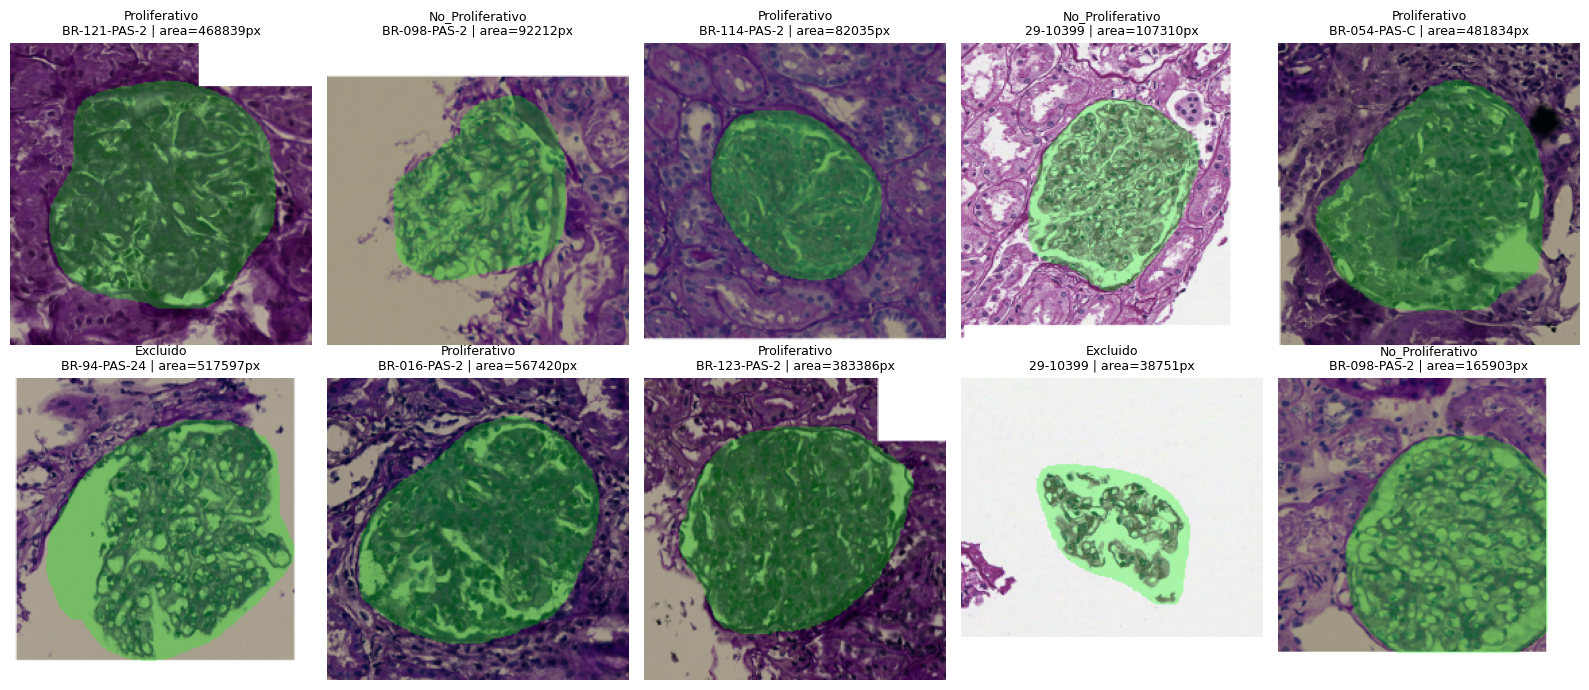

✓ Saved to Salidas\Clasificador\viz_10_glomeruli.png


In [16]:
# === VIZ-A: 10 glomerulos del dataset con sus máscaras ===
print("VIZ-A: 10 reconstructed glomeruli with masks")
if 'manifest_df' not in globals() or manifest_df is None or len(manifest_df) == 0:
    print("⚠️ manifest_df no existe o está vacío. Ejecuta primero la celda 'Build or Load Glomerulus Manifest' o el entrenamiento.")
else:
    random.seed(42)
    sample_indices = random.sample(range(len(manifest_df)), min(10, len(manifest_df)))
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    axes = axes.flatten()
    for plot_idx, df_idx in enumerate(sample_indices):
        row = manifest_df.iloc[df_idx]
        try:
            crop_rgb, class_mask, _, img_with_mask, area_px = manifest_overlay(
                row, color=(0, 255, 0), alpha=0.3
            )
            axes[plot_idx].imshow(img_with_mask)
            axes[plot_idx].set_title(
                f"{row['class_name']}\n{row['slide_id'][:12]} | area={area_px}px",
                fontsize=9,
            )
            axes[plot_idx].axis('off')
        except Exception as e:
            axes[plot_idx].text(0.5, 0.5, f"Error:\n{str(e)[:30]}", ha='center', va='center', fontsize=8)
            axes[plot_idx].axis('off')
    for ax in axes[len(sample_indices):]:
        ax.axis('off')
    plt.tight_layout()
    Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)
    plt.savefig(Path(CONFIG['output_dir']) / 'viz_10_glomeruli.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to {Path(CONFIG['output_dir']) / 'viz_10_glomeruli.png'}")


VIZ-B: Data augmentation effects (mask overlay in red)


c:\Users\proyecto_final\Documents\Proyecto_Final_Glomerulos\env\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


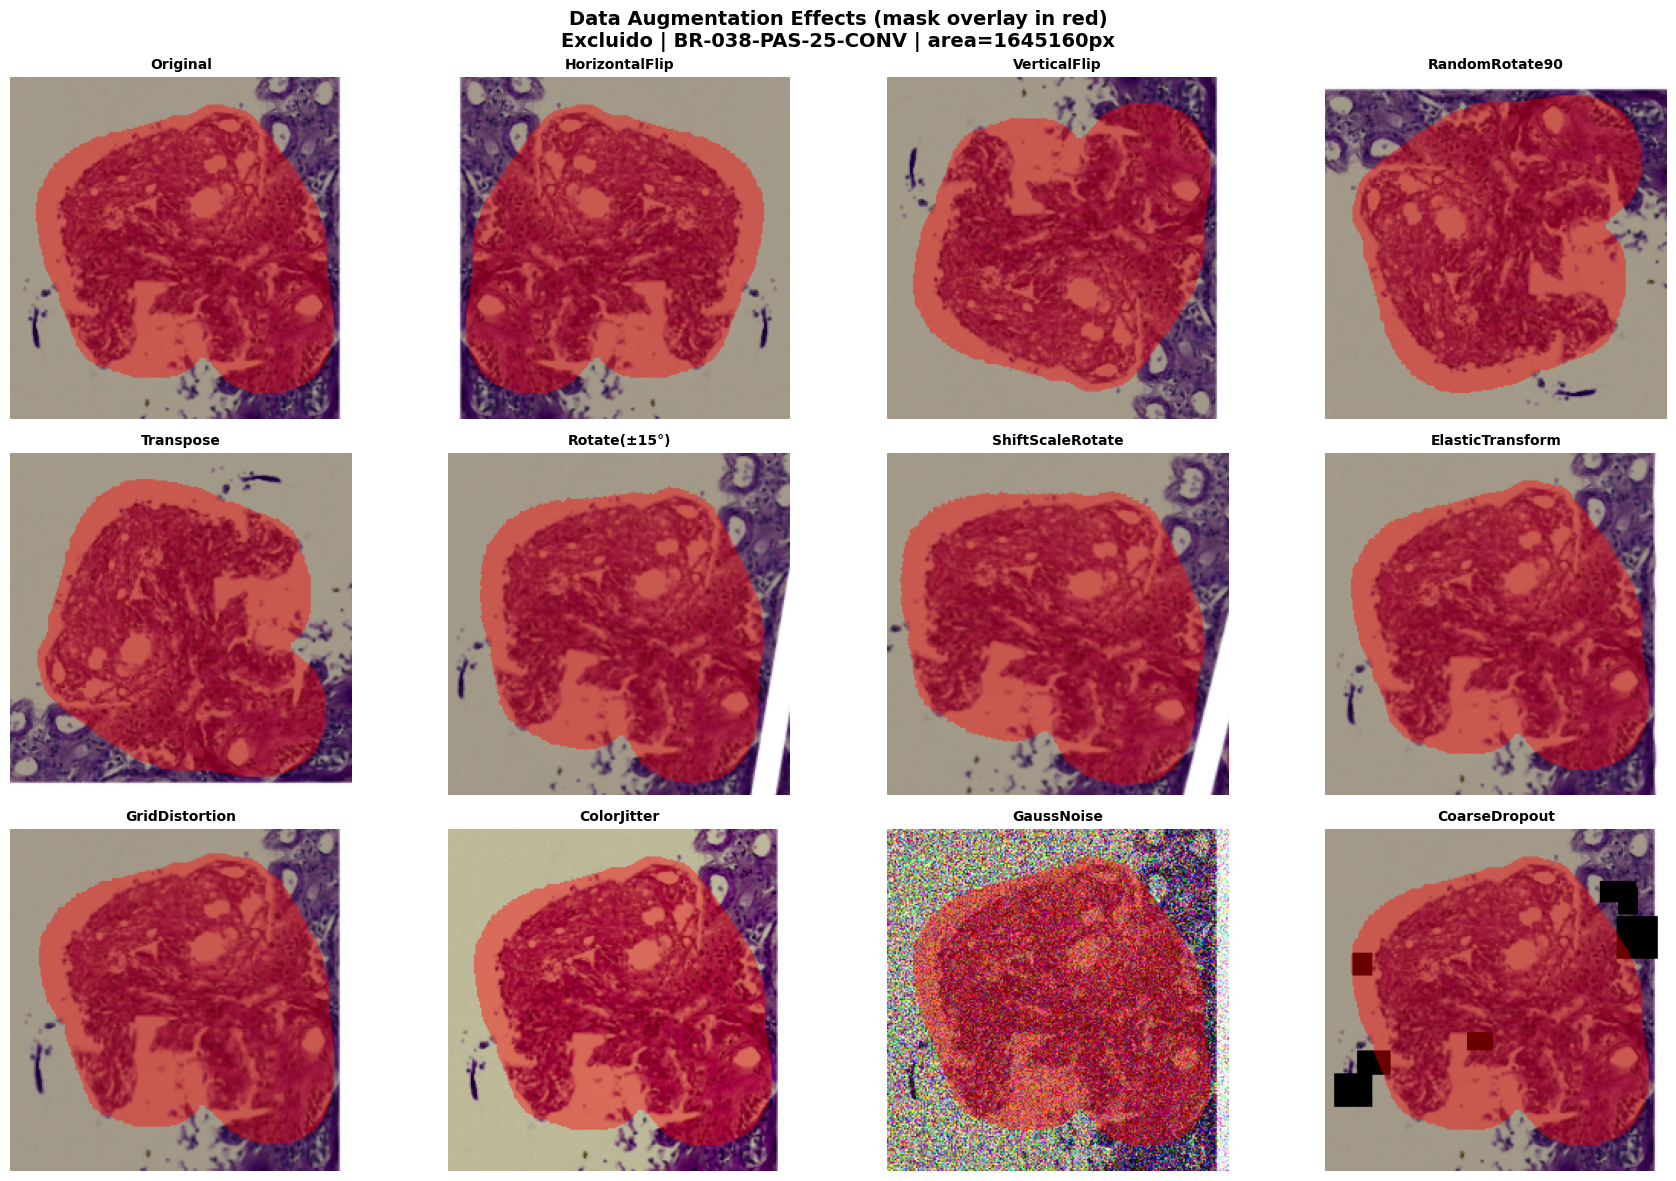

✓ Saved to Salidas\Clasificador\viz_augmentation_effects.png


In [17]:
# === VIZ-B: Data augmentation effects sobre glomérulo + máscara ===
print("VIZ-B: Data augmentation effects (mask overlay in red)")

if 'manifest_df' not in globals() or manifest_df is None or len(manifest_df) == 0:
    print("⚠️ manifest_df no existe o está vacío. Ejecuta primero la celda 'Build or Load Glomerulus Manifest'.")
else:
    train_manifest = manifest_df[manifest_df['split'] == 'train'].copy()
    if 'coverage_pct' in train_manifest.columns:
        train_manifest = train_manifest[train_manifest['coverage_pct'].fillna(100) >= 80]
    if 'component_touches_edge' in train_manifest.columns:
        train_manifest = train_manifest[~train_manifest['component_touches_edge'].fillna(False).astype(bool)]

    if len(train_manifest) == 0:
        print("⚠️ No train samples available for augmentation visualization")
    else:
        # Prefer a large, clean glomerulus so geometric augmentations are easy to inspect.
        if 'area_px' in train_manifest.columns:
            row = train_manifest.sort_values('area_px', ascending=False).iloc[0]
        else:
            row = train_manifest.sample(1, random_state=CONFIG['seed']).iloc[0]

        crop_rgb, crop_mask, _, _, _ = manifest_overlay(row, color=(255, 0, 0), alpha=0.42)

        def apply_aug(name, transform):
            if transform is None:
                return name, crop_rgb, crop_mask
            augmented = A.Compose([transform], additional_targets={'mask': 'mask'})(image=crop_rgb, mask=crop_mask)
            return name, augmented['image'], augmented['mask']

        aug_specs = [
            ('Original', None),
            ('HorizontalFlip', A.HorizontalFlip(p=1.0)),
            ('VerticalFlip', A.VerticalFlip(p=1.0)),
            ('RandomRotate90', A.RandomRotate90(p=1.0)),
            ('Transpose', A.Transpose(p=1.0)),
            ('Rotate(±15°)', A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT, p=1.0)),
            ('ShiftScaleRotate', A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.12, rotate_limit=15, border_mode=cv2.BORDER_REFLECT, p=1.0)),
            ('ElasticTransform', A.ElasticTransform(alpha=25, sigma=5, border_mode=cv2.BORDER_REFLECT, p=1.0)),
            ('GridDistortion', A.GridDistortion(num_steps=5, distort_limit=0.25, border_mode=cv2.BORDER_REFLECT, p=1.0)),
            ('ColorJitter', A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20, hue=0.05, p=1.0)),
            ('GaussNoise', A.GaussNoise(p=1.0)),
            ('CoarseDropout', A.CoarseDropout(num_holes_range=(4, 8), hole_height_range=(12, 28), hole_width_range=(12, 28), p=1.0)),
        ]

        fig, axes = plt.subplots(3, 4, figsize=(18, 12))
        axes = axes.flatten()
        for ax, (name, transform) in zip(axes, aug_specs):
            try:
                aug_name, aug_rgb, aug_mask = apply_aug(name, transform)
                overlay = make_mask_overlay(aug_rgb.astype(np.uint8), (aug_mask > 0).astype(np.uint8), color=(255, 0, 0), alpha=0.42)
                ax.imshow(overlay)
                ax.set_title(aug_name, fontsize=10, fontweight='bold')
                ax.axis('off')
            except Exception as e:
                ax.text(0.5, 0.5, f"{name}\nError:\n{str(e)[:45]}", ha='center', va='center', fontsize=8)
                ax.axis('off')

        area_px = int(row['area_px']) if 'area_px' in row and pd.notna(row['area_px']) else int(crop_mask.sum())
        plt.suptitle(
            f"Data Augmentation Effects (mask overlay in red)\n{row['class_name']} | {row['slide_id']} | area={area_px}px",
            fontsize=14,
            fontweight='bold',
        )
        plt.tight_layout()
        Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)
        out_path = Path(CONFIG['output_dir']) / 'viz_augmentation_effects.png'
        plt.savefig(out_path, dpi=120, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved to {out_path}")


In [18]:
# 4. Create datasets
# Requires manifest_df (from the manifest cell or train_classifier) and U-Net preprocessing stats.
if 'manifest_df' not in globals() or manifest_df is None or len(manifest_df) == 0:
    print("⚠️ manifest_df no existe o está vacío. Ejecuta primero la celda 'Build or Load Glomerulus Manifest'.")
elif not all(name in globals() for name in ['channel_means', 'channel_stds', 'reinhard_stats']):
    print("⚠️ Faltan channel_means/channel_stds/reinhard_stats. Ejecuta primero la celda de carga del checkpoint U-Net.")
else:
    dataset_train = GlomeruliClassificationDataset(
        manifest_df, CONFIG['images_dir'], CONFIG['masks_dir'], split='train',
        channel_means=channel_means, channel_stds=channel_stds, reinhard=reinhard_stats, config=CONFIG
    )
    dataset_val = GlomeruliClassificationDataset(
        manifest_df, CONFIG['images_dir'], CONFIG['masks_dir'], split='val',
        channel_means=channel_means, channel_stds=channel_stds, reinhard=reinhard_stats, config=CONFIG
    )
    dataset_test = GlomeruliClassificationDataset(
        manifest_df, CONFIG['images_dir'], CONFIG['masks_dir'], split='test',
        channel_means=channel_means, channel_stds=channel_stds, reinhard=reinhard_stats, config=CONFIG
    )
    loader_train, loader_val, loader_test = create_classification_dataloaders(
        dataset_train, dataset_val, dataset_test, CONFIG
    )
    print(f"✓ Dataloaders created: train={len(loader_train)}, val={len(loader_val)}, test={len(loader_test)}")


✓ Dataloaders created: train=39, val=6, test=11


In [19]:
# 5. Train classifier (protected: set RUN_TRAINING=True explicitly to execute)
RUN_TRAINING = True

if RUN_TRAINING:
    print("\n" + "="*80)
    print("TRAINING CLASSIFIER")
    print("="*80)
    model, train_history, manifest_df, test_metrics = train_classifier(CONFIG)
    print(f"\n✓ Training complete!")
    print(f"  Best balanced_acc: {train_history['best_balanced_acc']:.4f}")
    print(f"  Manifest instances: {len(manifest_df)}")
    print(f"    Train: {len(manifest_df[manifest_df['split']=='train'])}")
    print(f"    Val:   {len(manifest_df[manifest_df['split']=='val'])}")
    print(f"    Test:  {len(manifest_df[manifest_df['split']=='test'])}")
else:
    print("⏭️ Entrenamiento omitido. Cambia RUN_TRAINING=True para ejecutar train_classifier(CONFIG).")



TRAINING CLASSIFIER

Loading U-Net checkpoint: unet_binary_20260513_072214_best.pth
  ✓ Channel means: [0.5249426116573582, 0.4619087558025785, 0.4945691148938925]
  ✓ Channel stds: [0.12682547154319532, 0.15825028652078063, 0.06188548903405716]
✓ Split biopsias: train=46, val=11, test=11
✓ Loaded cached manifest: Salidas\Clasificador\manifest.csv (1729 instances)

=== MANIFEST DISTRIBUTION ===
Total instances: 1729

By class and split:
split             test  train  val   All
class_name                              
Esclerosado         14    157   15   186
Excluido            67    196   32   295
No_Proliferativo   209    495   53   757
Proliferativo       34    373   84   491
All                324   1221  184  1729

Top 10 biopsies by instance count:
slide_id
27-10041                   80
18-139                     74
BR-098-PAS-25-CONV         66
BR-94-PAS-24-CONV          58
BR-038-PAS-25-CONV         50
BR-123-PAS-24-OTRA-CONV    49
BR-105-PAS-25-CONV         48
29-10399        

C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_7432\2164567237.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)



Training default | Epochs: 80, Patience: 12, LR: 0.0003
  Train: 1174 | Val: 297 | Test: 258


train:   0%|          | 0/37 [00:00<?, ?it/s]C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_7432\2164567237.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_7432\2164567237.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch   1/80 | Loss T/V: 2.0654/1.6972 | Acc: 0.551/0.599 | P: 0.54/0.57 | R: 0.55/0.55 | F1: 0.54/0.55 | ★ best


...

Epoch  26/80 | Loss T/V: 0.1177/1.6312 | Acc: 0.959/0.673 | P: 0.96/0.65 | R: 0.96/0.66 | F1: 0.96/0.65 | wait 11/12


train:   0%|          | 0/37 [00:00<?, ?it/s]C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_7432\2164567237.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch  27/80 | Loss T/V: 0.1399/1.5149 | Acc: 0.945/0.677 | P: 0.95/0.66 | R: 0.94/0.64 | F1: 0.94/0.65 | wait 12/12
→ Early stopping at epoch 27



Classification Report:
                  precision    recall  f1-score   support

No_Proliferativo       0.77      0.62      0.69       129
   Proliferativo       0.50      0.72      0.59        65
     Esclerosado       0.42      0.33      0.37        15
        Excluido       0.65      0.63      0.64        49

        accuracy                           0.63       258
       macro avg       0.58      0.58      0.57       258
    weighted avg       0.66      0.63      0.64       258


Confusion Matrix:
[[80 35  2 12]
 [11 47  3  4]
 [ 3  6  5  1]
 [10  6  2 31]]
Confusion matrix guardada: Salidas\Clasificador\confusion_matrix_default.png
Classification report guardado: Salidas\Clasificador\classification_report_default.png

TRAINING COMPLETE
  Best test balanced_accuracy: 0.5773
  Test Precision: 0.5829
  Test Recall:    0.5773
  Test F1-Score:  0.5719
  Best model saved: Salidas\Clasificador\best_model_default.pth




FINAL RESULTS — default
Validation: Acc=0.697  P=0.707  R=0.669  F1=0.665
Test:       Acc=0.632  P=0.583  R=0.577  F1=0.572


✓ Training complete!
  Best balanced_acc: 0.5773
  Manifest instances: 1729
    Train: 1221
    Val:   184
    Test:  324


VIZ-C: Predictions vs Ground Truth


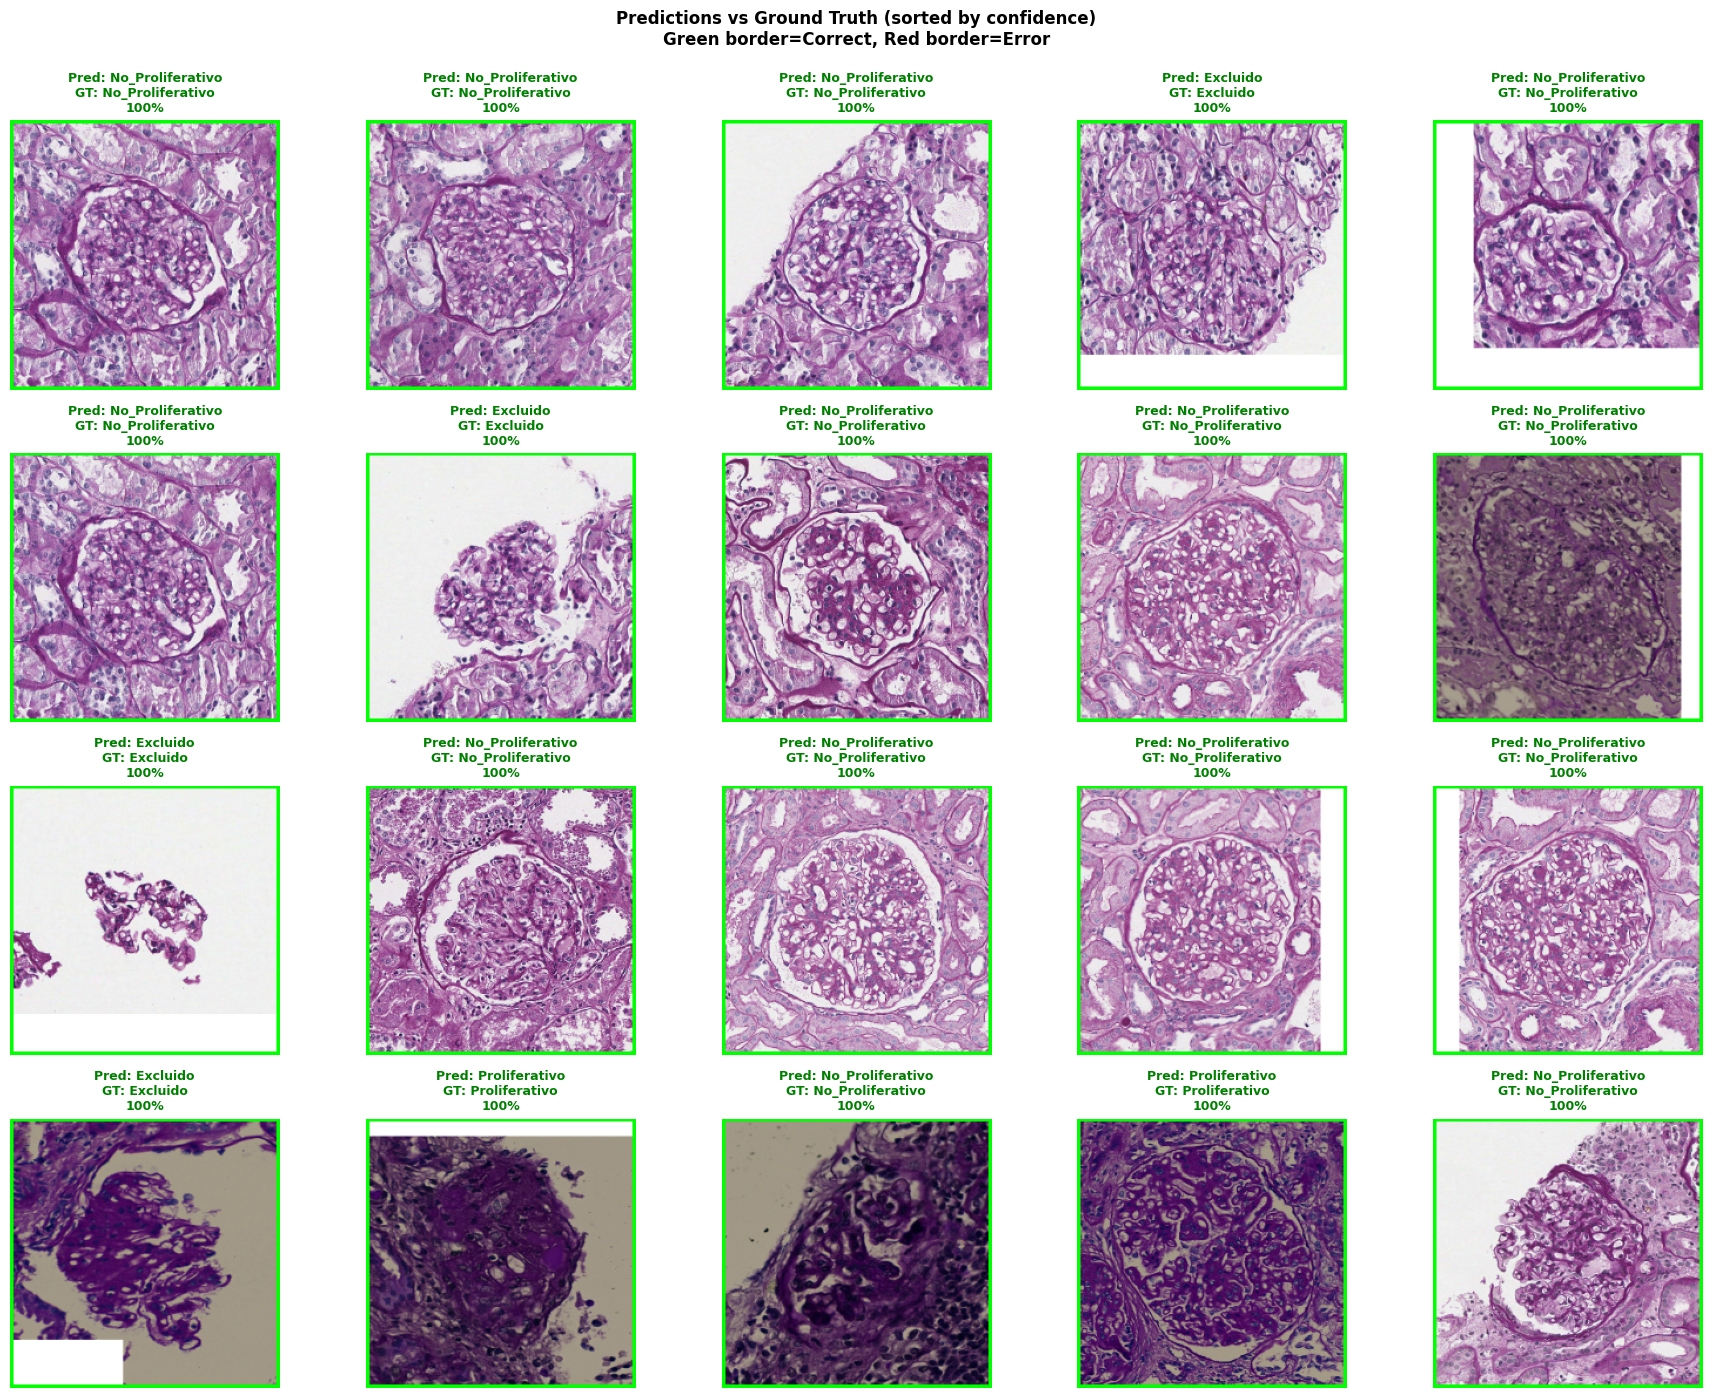

✓ Saved to Salidas\Clasificador\viz_predictions_vs_gt.png


In [20]:
# === VIZ-C: Predicciones vs Ground Truth (20 crops) ===
print("VIZ-C: Predictions vs Ground Truth")
required_names = ['manifest_df', 'model', 'channel_means', 'channel_stds', 'reinhard_stats']
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    print(f"⚠️ Faltan variables requeridas: {missing_names}. Ejecuta primero manifest/checkpoint/training.")
elif manifest_df is None or len(manifest_df) == 0:
    print("⚠️ manifest_df está vacío. Ejecuta primero la celda 'Build or Load Glomerulus Manifest' o el entrenamiento.")
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    preprocessing_params = {
        'images_dir': CONFIG['images_dir'],
        'masks_dir': CONFIG['masks_dir'],
        'input_size': CONFIG['input_size'],
        'mask_size': CONFIG['mask_size'],
        'margin_ratio': CONFIG['margin_ratio'],
        'channel_means': channel_means,
        'channel_stds': channel_stds,
        'reinhard': reinhard_stats,
    }
    test_manifest = manifest_df[manifest_df['split'] == 'test'].reset_index(drop=True)
    if len(test_manifest) == 0:
        print("⚠️ No test samples available")
    else:
        dataset_test_viz = GlomeruliClassificationDataset(
            test_manifest,
            config=CONFIG,
            split='test',
            **preprocessing_params,
        )
        loader_test_viz = DataLoader(dataset_test_viz, batch_size=1, shuffle=False, num_workers=0)
        model.eval()
        all_predictions = []
        all_labels = []
        all_probs = []
        with torch.no_grad():
            for batch in tqdm(loader_test_viz, desc="Inferencing", leave=False):
                x, y = batch['image'].to(device), batch['label'].to(device)
                logits = model(x)
                probs = torch.softmax(logits, dim=1)
                preds = torch.argmax(logits, dim=1)
                all_predictions.append(preds.cpu().numpy()[0])
                all_labels.append(y.cpu().numpy()[0])
                all_probs.append(probs.cpu().numpy()[0])
        all_predictions = np.array(all_predictions)
        all_labels = np.array(all_labels)
        all_probs = np.array(all_probs)
        confidences = np.max(all_probs, axis=1)
        sorted_idx = np.argsort(-confidences)
        n_show = min(20, len(sorted_idx))
        sorted_idx = sorted_idx[:n_show]
        fig, axes = plt.subplots(4, 5, figsize=(18, 14))
        axes = axes.flatten()
        for plot_idx, manifest_idx in enumerate(sorted_idx):
            row = test_manifest.iloc[manifest_idx]
            pred_class_id = int(all_predictions[manifest_idx])
            label_class_id = int(all_labels[manifest_idx])
            confidence = float(confidences[manifest_idx])
            is_correct = (pred_class_id == label_class_id)
            try:
                crop_rgb = load_rgb_image(row['fused_crop_path'])
                crop_rgb = cv2.resize(crop_rgb, (CONFIG['input_size'], CONFIG['input_size']))
                border_color = (0, 255, 0) if is_correct else (255, 0, 0)
                crop_with_border = cv2.copyMakeBorder(crop_rgb, 3, 3, 3, 3, cv2.BORDER_CONSTANT, value=border_color)
                axes[plot_idx].imshow(crop_with_border)
                pred_name = CLASS_NAMES[pred_class_id]
                label_name = CLASS_NAMES[label_class_id]
                axes[plot_idx].set_title(
                    f"Pred: {pred_name}\nGT: {label_name}\n{confidence:.0%}",
                    fontsize=9,
                    color='green' if is_correct else 'red',
                    fontweight='bold' if is_correct else 'normal',
                )
                axes[plot_idx].axis('off')
            except Exception as e:
                axes[plot_idx].text(0.5, 0.5, f"Error:\n{str(e)[:25]}", ha='center', va='center', fontsize=8)
                axes[plot_idx].axis('off')
        for ax in axes[n_show:]:
            ax.axis('off')
        plt.suptitle(
            "Predictions vs Ground Truth (sorted by confidence)\nGreen border=Correct, Red border=Error",
            fontsize=12,
            fontweight='bold',
            y=0.995,
        )
        plt.tight_layout()
        Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)
        plt.savefig(Path(CONFIG['output_dir']) / 'viz_predictions_vs_gt.png', dpi=100, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved to {Path(CONFIG['output_dir']) / 'viz_predictions_vs_gt.png'}")


In [21]:
# === BASELINE EXPERIMENTS ===
# Entrenar 4 baselines en orden: GoogLeNet RGB → EfficientNet-B0 RGB → B0 RGB+mask → B2 RGB+mask
BASELINE_EXPERIMENTS = [
    {
        'name': 'efficientnet_b0_rgb',
        'backbone': 'efficientnet_b0',
        'input_mode': 'rgb_only',
        'input_size': 224,
        'batch_size': 32,
        'lr': 3e-4,
        'max_epochs': 80,
        'early_stopping_patience': 12,
        'loss_fn': 'cross_entropy',
        'description': 'Baseline moderno: EfficientNet-B0 con entrada RGB-only',
    },
    {
        'name': 'efficientnet_b0_rgb_mask',
        'backbone': 'efficientnet_b0',
        'input_mode': 'rgb_mask_manual',
        'input_size': 224,
        'batch_size': 32,
        'lr': 3e-4,
        'max_epochs': 80,
        'early_stopping_patience': 12,
        'loss_fn': 'cross_entropy',
        'description': 'Propuesta actual: EfficientNet-B0 con RGB + máscara binaria',
    },
    {
        'name': 'efficientnet_b2_rgb_mask',
        'backbone': 'efficientnet_b2',
        'input_mode': 'rgb_mask_manual',
        'input_size': 288,
        'batch_size': 32,
        'lr': 3e-4,
        'max_epochs': 80,
        'early_stopping_patience': 12,
        'loss_fn': 'cross_entropy',
        'description': 'Mayor capacidad: EfficientNet-B2 con RGB + máscara (288px)',
    },
]

print(f"\nBaselines a entrenar ({len(BASELINE_EXPERIMENTS)}):") 
for exp in BASELINE_EXPERIMENTS:
    print(f"  {exp['name']}: {exp['description']}")


Baselines a entrenar (3):
  efficientnet_b0_rgb: Baseline moderno: EfficientNet-B0 con entrada RGB-only
  efficientnet_b0_rgb_mask: Propuesta actual: EfficientNet-B0 con RGB + máscara binaria
  efficientnet_b2_rgb_mask: Mayor capacidad: EfficientNet-B2 con RGB + máscara (288px)


In [23]:
# === BASELINE RUNNER ===
# Protected: set RUN_BASELINES=True explicitly to train all baselines.
RUN_BASELINES = True


def run_baseline_experiments(baseline_experiments, base_config):
    """Train configured baselines sequentially and save a comparison CSV."""
    baseline_results = []
    for exp in baseline_experiments:
        exp_name = exp['name']
        print(f"\n{'='*80}")
        print(f"ENTRENANDO BASELINE: {exp_name}")
        print(f"  {exp['description']}")
        print(f"{'='*80}")

        exp_config = base_config.copy()
        exp_config.update({
            'backbone': exp['backbone'],
            'input_mode': exp['input_mode'],
            'input_size': exp['input_size'],
            'batch_size': exp.get('batch_size', base_config['batch_size']),
            'lr': exp.get('lr', base_config['lr']),
            'max_epochs': exp.get('max_epochs', base_config['max_epochs']),
            'early_stopping_patience': exp.get('early_stopping_patience', base_config['early_stopping_patience']),
            'loss_fn': exp.get('loss_fn', base_config.get('loss_fn', 'cross_entropy')),
        })

        try:
            _, history, _, _ = train_classifier(exp_config)
            test_balanced_acc = history.get('best_balanced_acc', -1.0)
            baseline_results.append({
                'experiment': exp_name,
                'backbone': exp['backbone'],
                'input_mode': exp['input_mode'],
                'input_size': exp['input_size'],
                'test_balanced_acc': test_balanced_acc,
            })
            print(f"✓ {exp_name} completado")
            print(f"  Test Balanced Acc: {test_balanced_acc:.4f}")
        except Exception as e:
            print(f"✗ ERROR en {exp_name}: {e}")
            import traceback
            traceback.print_exc()
            baseline_results.append({
                'experiment': exp_name,
                'backbone': exp['backbone'],
                'input_mode': exp['input_mode'],
                'input_size': exp['input_size'],
                'test_balanced_acc': None,
                'error': str(e),
            })

    baseline_results_df = pd.DataFrame(baseline_results)
    output_dir = Path(base_config['output_dir'])
    output_dir.mkdir(parents=True, exist_ok=True)
    results_csv = output_dir / 'baseline_results.csv'
    baseline_results_df.to_csv(results_csv, index=False)

    print(f"\n{'='*80}")
    print(f"RESULTADOS GUARDADOS EN: {results_csv}")
    print(f"{'='*80}")
    print(baseline_results_df.to_string())
    return baseline_results_df


if RUN_BASELINES:
    baseline_results_df = run_baseline_experiments(BASELINE_EXPERIMENTS, CONFIG)
else:
    print("⏭️ Baselines omitidos. Cambia RUN_BASELINES=True para ejecutar los experimentos.")



ENTRENANDO BASELINE: efficientnet_b0_rgb
  Baseline moderno: EfficientNet-B0 con entrada RGB-only

Loading U-Net checkpoint: unet_binary_20260513_072214_best.pth
  ✓ Channel means: [0.5249426116573582, 0.4619087558025785, 0.4945691148938925]
  ✓ Channel stds: [0.12682547154319532, 0.15825028652078063, 0.06188548903405716]
✓ Split biopsias: train=46, val=11, test=11
✓ Loaded cached manifest: Salidas\Clasificador\manifest.csv (1729 instances)

=== MANIFEST DISTRIBUTION ===
Total instances: 1729

By class and split:
split             test  train  val   All
class_name                              
Esclerosado         14    157   15   186
Excluido            67    196   32   295
No_Proliferativo   209    495   53   757
Proliferativo       34    373   84   491
All                324   1221  184  1729

Top 10 biopsies by instance count:
slide_id
27-10041                   80
18-139                     74
BR-098-PAS-25-CONV         66
BR-94-PAS-24-CONV          58
BR-038-PAS-25-CONV         5

C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_7432\2164567237.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
train:   0%|          | 0/37 [00:00<?, ?it/s]C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_7432\2164567237.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_7432\2164567237.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch   1/80 | Loss T/V: 2.1456/1.5272 | Acc: 0.531/0.660 | P: 0.53/0.62 | R: 0.53/0.63 | F1: 0.52/0.62 | ★ best


train:   0%|          | 0/37 [00:00<?, ?it/s]C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_7432\2164567237.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_7432\2164567237.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch   2/80 | Loss T/V: 0.9141/1.7921 | Acc: 0.724/0.569 | P: 0.72/0.51 | R: 0.72/0.53 | F1: 0.72/0.51 | wait 1/12


...

Epoch  19/80 | Loss T/V: 0.1952/1.8556 | Acc: 0.922/0.640 | P: 0.92/0.61 | R: 0.93/0.59 | F1: 0.92/0.58 | wait 11/12


train:   0%|          | 0/37 [00:00<?, ?it/s]C:\Users\proyecto_final\AppData\Local\Temp\ipykernel_7432\2164567237.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch  20/80 | Loss T/V: 0.1888/1.7767 | Acc: 0.937/0.684 | P: 0.94/0.67 | R: 0.94/0.65 | F1: 0.94/0.65 | wait 12/12
→ Early stopping at epoch 20



Classification Report:
                  precision    recall  f1-score   support

No_Proliferativo       0.82      0.67      0.74       129
   Proliferativo       0.57      0.86      0.69        65
     Esclerosado       0.65      0.73      0.69        15
        Excluido       0.70      0.53      0.60        49

        accuracy                           0.70       258
       macro avg       0.69      0.70      0.68       258
    weighted avg       0.73      0.70      0.70       258


Confusion Matrix:
[[87 32  3  7]
 [ 5 56  0  4]
 [ 1  3 11  0]
 [13  7  3 26]]
Confusion matrix guardada: Salidas\Clasificador\confusion_matrix_default.png
Classification report guardado: Salidas\Clasificador\classification_report_default.png

TRAINING COMPLETE
  Best test balanced_accuracy: 0.7000
  Test Precision: 0.6855
  Test Recall:    0.7000
  Test F1-Score:  0.6799
  Best model saved: Salidas\Clasificador\best_model_default.pth




FINAL RESULTS — default
Validation: Acc=0.704  P=0.715  R=0.674  F1=0.684
Test:       Acc=0.698  P=0.685  R=0.700  F1=0.680

✓ efficientnet_b2_rgb_mask completado
  Test Balanced Acc: 0.7000

RESULTADOS GUARDADOS EN: Salidas\Clasificador\baseline_results.csv
                 experiment         backbone       input_mode  input_size  test_balanced_acc
0       efficientnet_b0_rgb  efficientnet_b0         rgb_only         224           0.660559
1  efficientnet_b0_rgb_mask  efficientnet_b0  rgb_mask_manual         224           0.648991
2  efficientnet_b2_rgb_mask  efficientnet_b2  rgb_mask_manual         288           0.699976
